# ⚡ Regional Energy Market Price Prediction & Manufacturing Strategy Optimizer

This notebook builds a full-stack energy price forecasting and strategic planning system for a major manufacturer. It covers:

- **Tactical forecasting**: 30/60/90-day energy price predictions
- **Strategic planning**: Annual peak-price risk calendar, shutdown scheduling, and energy reserve buildups
- **Demand Response**: Modeling utility incentive programs that pay the manufacturer to be offline during grid stress events
- **Data drivers**: Regional demographics, commodity prices, weather (HDD/CDD), job openings, and consumer foot traffic

---
> **How to use this notebook**: Run all cells top-to-bottom. Synthetic data is generated by default so no API keys are required to get started. Replace synthetic loaders with real data sources (EIA API, NOAA, BLS, Placer.ai, etc.) as needed.

**Sections:**
1. Import Required Libraries
2. Load and Explore Raw Data Sources
3. Data Preprocessing and Feature Engineering
4. Exploratory Data Analysis (EDA) and Correlation Analysis
5. Time Series Decomposition of Energy Prices
6. Build Baseline Forecasting Model (Prophet / SARIMA)
7. Build Advanced ML Forecasting Model (XGBoost + SHAP)
8. Peak Price Period Detection
9. Demand Response & Utility Incentive Modeling
10. Shutdown and Reserve Strategy Optimizer
11. Tactical vs Strategic Planning Dashboard

## Section 1 — Import Required Libraries

Install and import all dependencies. The cell below installs missing packages automatically.

In [169]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q", "--user"])

required = [
    "pandas", "numpy", "scikit-learn", "xgboost>=1.6,<3.0", "lightgbm",
    "statsmodels", "matplotlib", "seaborn", "plotly", "scipy",
    "shap", "prophet", "pulp", "holidays", "requests", "python-dotenv"
]
for pkg in required:
    bare = pkg.split(">=")[0].split("==")[0].split("<")[0].replace("-", "_")
    try:
        __import__(bare)
        # For versioned requirements, let pip verify and install/upgrade if needed
        if any(op in pkg for op in [">=", "==", "<"]):
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", pkg, "-q", "--user"],
                stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
            )
    except ImportError:
        print(f"Installing {pkg}...")
        install(pkg)

print("✅ All packages ready.")


Installing scikit-learn...
Installing python-dotenv...
✅ All packages ready.


In [170]:
import os, requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

# ── Load API keys from .env (kept out of git) ──────────────────────────────
try:
    from dotenv import load_dotenv
    _env_path = os.path.join(os.path.dirname(os.path.abspath("__file__")), ".env")
    load_dotenv(_env_path, override=False)   # won't overwrite keys already in environment
    print(f"✅ Loaded .env from: {_env_path}")
except ImportError:
    print("⚠️  python-dotenv not installed — re-run cell 3 first.")

# Stats & ML
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb
import shap
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from scipy import stats, optimize
import holidays

# Plotting defaults
plt.rcParams.update({"figure.figsize": (14, 5), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11})
sns.set_palette("husl")

# ── Facility & market configuration ────────────────────────────────────────
REGION   = "ISO New England (ISO-NE)"
TODAY    = pd.Timestamp.today().normalize()        # always the current date
YEAR     = TODAY.year                              # current calendar year
FACILITY_MW = 85                 # Manufacturer peak load in MW
SHUTDOWN_COST_PER_HOUR = 12_500  # $ operational cost per shutdown hour
INCENTIVE_RATE = 45              # $ / MWh paid by utility for demand reduction
RESERVE_CAPACITY_MWH = 500       # On-site battery/reserve capacity in MWh

# ── Profit-sell threshold (energy component only) ──────────────────────────
# The spot LMP at which selling back to the grid earns more than production.
# NOTE: The full cost model below (capacity + T&D) adjusts this automatically.
PROFIT_THRESHOLD_MWH = 200       # $/MWh  (default $200 — edit to your margin)

# ── ISO-NE Forward Capacity Market (FCM) parameters ───────────────────────
# Capacity charges are typically the PRIMARY profitability driver for large
# industrial customers — often larger than the energy component on a $/MWh
# basis once spread over annual consumption.
#
# HOW IT WORKS:
#   • ISO-NE auctions capacity ~3 years ahead (Forward Capacity Auction / FCA)
#   • Your "capacity tag" = your MW load during the ISO-NE annual system peak
#     (typically ONE hot July or August weekday afternoon)
#   • Annual bill = capacity_tag_kW × FCM_price × 12 months
#   • Curtailing JUST THOSE PEAK HOURS can eliminate the entire annual bill
#
# UPDATE CAPACITY_PRICE_KW_MONTH each year when ISO-NE publishes FCA results:
#   → iso-ne.com/markets-operations/markets/forward-capacity-market/
CAPACITY_PRICE_KW_MONTH = 3.58   # $/kW-month — ISO-NE FCA #17 (2026/2027 period)
CAPACITY_TAG_FRACTION   = 1.0    # % of FACILITY_MW that is "on" during system peak
                                  # 1.0 = never curtail peak (full tag, max bill)
                                  # 0.0 = always curtail peak (zero tag, zero bill)
ANNUAL_CAPACITY_FACTOR  = 0.80   # Avg load factor: fraction of MW × 8760 hrs/yr consumed
TRANSMISSION_ADDER_MWH  = 8.0    # $/MWh — ISO-NE network transmission (semi-fixed)

# ── API Keys — loaded from .env (see .env file in project root) ────────────
# To add more keys, edit .env — it is listed in .gitignore and will NOT be
# pushed to GitHub, so your credentials stay private.
#
# Register free keys at:
#   EIA    → https://www.eia.gov/opendata/register.php
#   NOAA   → https://www.ncdc.noaa.gov/cdo-web/token
#   BLS    → https://www.bls.gov/developers/  (v1 works without a key)
#   Census → https://api.census.gov/data/key_signup.html

EIA_API_KEY    = os.environ.get("EIA_API_KEY",    "")
NOAA_TOKEN     = os.environ.get("NOAA_CDO_TOKEN",  "")
BLS_API_KEY    = os.environ.get("BLS_API_KEY",    "")
CENSUS_API_KEY = os.environ.get("CENSUS_API_KEY", "")

# EIA hub / RTO identifiers for New England
EIA_ELEC_HUB = "ISNE.HUB"            # ISO-NE hub  (MISO: MIDW.HUB, PJM: MIDA.HUB, ERCOT: ERCO.HUB)
NOAA_STATION = "GHCND:USW00014739"   # Boston Logan — representative ISO-NE station
CENSUS_FIPS  = "25"                  # Massachusetts state FIPS code

keys_set = [k for k, v in {"EIA": EIA_API_KEY, "NOAA": NOAA_TOKEN,
                             "Census": CENSUS_API_KEY}.items() if v]
print(f"✅ Config: {REGION}  |  {FACILITY_MW} MW  |  Reserve {RESERVE_CAPACITY_MWH} MWh  |  ${INCENTIVE_RATE}/MWh incentive")
print(f"   Profit-sell threshold : ${PROFIT_THRESHOLD_MWH}/MWh (energy only)")
print(f"   Capacity (FCM)        : ${CAPACITY_PRICE_KW_MONTH}/kW-month  "
      f"|  Tag fraction {CAPACITY_TAG_FRACTION*100:.0f}%  |  Load factor {ANNUAL_CAPACITY_FACTOR*100:.0f}%")
print(f"   API keys active: {', '.join(keys_set) if keys_set else 'none — will use synthetic fallbacks'}")

✅ Loaded .env from: c:\EnergyForecast\.env
✅ Config: ISO New England (ISO-NE)  |  85 MW  |  Reserve 500 MWh  |  $45/MWh incentive
   Profit-sell threshold : $200/MWh (energy only)
   Capacity (FCM)        : $3.58/kW-month  |  Tag fraction 100%  |  Load factor 80%
   API keys active: EIA


## Section 2 — Load Raw Data Sources

Each loader below **tries a live API first** and falls back silently to synthetic data when an API key is not configured. Keys are stored in `.env` (excluded from git) and loaded automatically by the config cell.

| Data Source | Live API Provider | Key Variable | Notes |
|---|---|---|---|
| Electricity prices ($/MWh) | [EIA Retail-Sales, Industrial sector (IL)](https://www.eia.gov/opendata/browser/electricity/retail-sales) | `EIA_API_KEY` | Monthly avg × 10 → daily; best public proxy for MISO energy costs |
| Weather (temp, HDD/CDD) | [NOAA Climate Data Online (CDO) API](https://www.ncdc.noaa.gov/cdo-web/webservices/v2) | `NOAA_CDO_TOKEN` | Daily TMAX/TMIN at Chicago O'Hare (MISO proxy) |
| Natural gas spot price | [EIA Henry Hub Futures (RNGWHHD)](https://www.eia.gov/opendata/browser/natural-gas/pri/fut) | `EIA_API_KEY` | ✅ Active |
| WTI crude oil spot price | [EIA Petroleum Spot Price (RWTC)](https://www.eia.gov/opendata/browser/petroleum/pri/spt) | `EIA_API_KEY` | ✅ Active |
| Coal spot price | [EIA Coal Price API](https://www.eia.gov/opendata/browser/coal/price-by-rank-and-mine-type) | `EIA_API_KEY` | Monthly |
| Job openings (JOLTS) | [BLS Public Data API v2](https://www.bls.gov/developers/) | `BLS_API_KEY` (optional) | ✅ Active — no key needed for v1 |
| Regional population | [US Census Bureau ACS API](https://api.census.gov/data/key_signup.html) | `CENSUS_API_KEY` | Annual, interpolated to daily |
| Consumer foot traffic | Placer.ai / SafeGraph / Google Mobility (paid) | Replace synthetic block in cell | Replace code block with your feed |

> **Security note**: API keys are stored in `.env` at the project root. This file is listed in `.gitignore` and will never be pushed to GitHub.


In [171]:
np.random.seed(42)

# ── Date range (shared by all sources) ────────────────────────────────────
START_DATE = "2020-01-01"
END_DATE   = TODAY.strftime("%Y-%m-%d")           # today — APIs will return whatever exists up to this
dates      = pd.date_range(START_DATE, END_DATE, freq="D")
n          = len(dates)

data_sources = {}   # records "live" vs "synthetic" for each feed

# ══════════════════════════════════════════════════════════════════════════
# Helpers
# ══════════════════════════════════════════════════════════════════════════

def _get_json(url, headers=None, params=None, timeout=30):
    """GET request → parsed JSON, or None on any error."""
    try:
        r = requests.get(url, headers=headers or {}, params=params or {}, timeout=timeout)
        r.raise_for_status()
        return r.json()
    except Exception:
        return None

def _reindex(series, new_index):
    """Align a pd.Series to `new_index`, forward-then-back fill gaps."""
    return series.reindex(new_index).ffill().bfill()

def _eia_v2(route, facets, start=START_DATE, end=END_DATE, value_col="value", date_col="period"):
    """Fetch a daily EIA API v2 series. Returns a date-indexed pd.Series or None."""
    if not EIA_API_KEY:
        return None
    params = {
        "api_key":              EIA_API_KEY,
        "frequency":            "daily",
        "data[0]":              value_col,
        "start":                start,
        "end":                  end,
        "sort[0][column]":      date_col,
        "sort[0][direction]":   "asc",
        "length":               5000,
    }
    params.update(facets)
    url = f"https://api.eia.gov/v2/{route}/data/"
    j   = _get_json(url, params=params)
    if j and "response" in j and j["response"].get("data"):
        df = pd.DataFrame(j["response"]["data"])[[date_col, value_col]].copy()
        df[date_col]  = pd.to_datetime(df[date_col], errors="coerce")
        df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
        s = df.dropna().sort_values(date_col).set_index(date_col)[value_col]
        return _reindex(s, dates)
    return None

# ══════════════════════════════════════════════════════════════════════════
# 1. ELECTRICITY PRICES  —  EIA Retail Sales, Industrial Sector (Illinois)
#    EIA does not publish raw wholesale LMP through the public v2 API.
#    Illinois industrial retail price (cents/kWh → $/MWh) is the best
#    available public proxy for MISO effective energy costs (~$60-80/MWh).
#    Docs: https://www.eia.gov/opendata/browser/electricity/retail-sales
# ══════════════════════════════════════════════════════════════════════════

def _eia_retail_price(state_id="IL", sector_id="IND"):
    """
    Fetch monthly EIA retail electricity price (cents/kWh) for a state+sector,
    convert to $/MWh, and forward-fill to a daily series aligned to `dates`.
    Returns a date-indexed pd.Series or None.
    """
    if not EIA_API_KEY:
        return None
    j = _get_json(
        "https://api.eia.gov/v2/electricity/retail-sales/data/",
        params={
            "api_key":            EIA_API_KEY,
            "facets[stateid][]":  state_id,
            "facets[sectorid][]": sector_id,
            "frequency":          "monthly",
            "data[0]":            "price",
            "start":              START_DATE[:7],
            "end":                END_DATE[:7],
            "sort[0][column]":    "period",
            "sort[0][direction]": "asc",
            "length":             200,
        },
    )
    if not (j and j.get("response", {}).get("data")):
        return None
    rows = j["response"]["data"]
    records = []
    for row in rows:
        try:
            records.append({
                "date":  pd.to_datetime(row["period"] + "-01"),
                "price": float(row["price"]) * 10.0,   # cents/kWh → $/MWh
            })
        except (KeyError, ValueError):
            continue
    if not records:
        return None
    s = pd.DataFrame(records).sort_values("date").set_index("date")["price"]
    return _reindex(s, dates)

lmp_series = _eia_retail_price(state_id="CT", sector_id="IND")

if lmp_series is not None and lmp_series.notna().sum() > 30:
    # Add seasonal noise and rare spikes to inflate the monthly averages into
    # a realistic daily pattern while preserving the real price trend.
    _lmp_base = lmp_series.values.copy()
    _noise    = np.random.normal(0, _lmp_base.std() * 0.15, n)
    _spikes   = np.where(np.random.random(n) < 0.015, np.random.uniform(20, 60, n), 0)
    df_energy = pd.DataFrame({"date": dates,
                               "lmp_price": np.clip(_lmp_base + _noise + _spikes, 5, 250)})
    data_sources["Energy (LMP)"] = "🌐 EIA Retail-Sales Industrial (CT/NE) — monthly avg → daily (cents/kWh × 10)"
else:
    # Synthetic fallback: seasonal + trend + noise + rare spikes
    seasonal  = (18 * np.sin(2 * np.pi * np.arange(n) / 365 + np.pi)
                + 10 * np.sin(4 * np.pi * np.arange(n) / 365))
    trend     = np.linspace(0, 8, n)
    noise     = np.random.normal(0, 6, n)
    spikes    = np.where(np.random.random(n) < 0.015, np.random.uniform(60, 120, n), 0)
    df_energy = pd.DataFrame({"date": dates,
                               "lmp_price": np.clip(45 + seasonal + trend + noise + spikes, 5, 250)})
    reason = "EIA_API_KEY not set" if not EIA_API_KEY else "EIA retail-sales returned no data"
    data_sources["Energy (LMP)"] = f"⚠️  Synthetic ({reason})"

# ══════════════════════════════════════════════════════════════════════════
# 2. WEATHER  —  NOAA Climate Data Online Daily Summaries (GHCND)
#    Station: Chicago O'Hare (USW00094846) — representative for MISO
#    Docs: https://www.ncdc.noaa.gov/cdo-web/webservices/v2
#    Token: https://www.ncdc.noaa.gov/cdo-web/token
# ══════════════════════════════════════════════════════════════════════════

def _fetch_noaa_year(year, token, station):
    """Fetch one calendar year of NOAA GHCND daily TMAX/TMIN for a station."""
    j = _get_json(
        "https://www.ncei.noaa.gov/cdo-web/api/v2/data",
        headers={"token": token},
        params={
            "datasetid":  "GHCND",
            "stationid":  station,
            "datatypeid": "TMAX,TMIN",
            "startdate":  f"{year}-01-01",
            "enddate":    f"{year}-12-31",
            "units":      "standard",   # °F
            "limit":      1000,
        },
    )
    return j.get("results", []) if j else []

if NOAA_TOKEN:
    raw_noaa = []
    for yr in range(int(START_DATE[:4]), int(END_DATE[:4]) + 1):
        raw_noaa.extend(_fetch_noaa_year(yr, NOAA_TOKEN, NOAA_STATION))

    if raw_noaa:
        wnr = pd.DataFrame(raw_noaa)
        wnr["date"]  = pd.to_datetime(wnr["date"]).dt.normalize()
        wnr["value"] = pd.to_numeric(wnr["value"], errors="coerce")
        piv  = wnr.pivot_table(index="date", columns="datatype", values="value", aggfunc="mean")
        tmax = _reindex(piv.get("TMAX", pd.Series(dtype=float)), dates)
        tmin = _reindex(piv.get("TMIN", pd.Series(dtype=float)), dates)
        temp_f = (tmax.values + tmin.values) / 2.0
        # Sanity check: CDO standard units are whole °F; if values look like tenths, rescale
        if np.nanmean(temp_f) > 150:
            temp_f = temp_f / 10.0
        hum_proxy = 55 + 20 * np.sin(2 * np.pi * np.arange(n) / 365) + np.random.normal(0, 5, n)
        df_weather = pd.DataFrame({
            "date":         dates,
            "temp_f":       np.where(np.isnan(temp_f),
                                     55 + 30 * np.sin(2 * np.pi * np.arange(n) / 365 - np.pi / 2),
                                     temp_f),
            "humidity_pct": hum_proxy,
            "hdd":          np.maximum(0, 65 - temp_f),
            "cdd":          np.maximum(0, temp_f - 65),
        })
        data_sources["Weather"] = f"🌐 NOAA CDO Daily Summaries — {NOAA_STATION}"
    else:
        NOAA_TOKEN = ""  # force fallback below
        data_sources["Weather"] = "⚠️  Synthetic (NOAA returned no data — check station/token)"

if not NOAA_TOKEN:
    temp_base  = 55 + 30 * np.sin(2 * np.pi * np.arange(n) / 365 - np.pi / 2)
    temperature = temp_base + np.random.normal(0, 5, n)
    humidity    = 55 + 20 * np.sin(2 * np.pi * np.arange(n) / 365) + np.random.normal(0, 8, n)
    df_weather  = pd.DataFrame({
        "date":         dates,
        "temp_f":       temperature,
        "humidity_pct": humidity,
        "hdd":          np.maximum(0, 65 - temperature),
        "cdd":          np.maximum(0, temperature - 65),
    })
    if "Weather" not in data_sources:
        data_sources["Weather"] = "⚠️  Synthetic (NOAA_CDO_TOKEN not set)"

# ══════════════════════════════════════════════════════════════════════════
# 3. COMMODITY PRICES  —  EIA: Henry Hub Natural Gas + WTI Crude Oil
#    Natural gas: https://www.eia.gov/opendata/browser/natural-gas/pri/fut
#    Petroleum:   https://www.eia.gov/opendata/browser/petroleum/pri/spt
# ══════════════════════════════════════════════════════════════════════════

gas_series  = _eia_v2("natural-gas/pri/fut",  {"facets[series][]": "RNGWHHD"})
oil_series  = _eia_v2("petroleum/pri/spt",    {"facets[series][]": "RWTC"})

# Coal spot prices are monthly in EIA — fetch monthly, ffill to daily
coal_series = _eia_v2("coal/price-by-rank-and-mine-type",
                       {"facets[coalRankId][]": "ALL", "facets[locationId][]": "NUS"},
                       start=START_DATE[:7], end=END_DATE[:7])

gas_base   = 3.5  + np.cumsum(np.random.normal(0, 0.04, n))
coal_base  = 60   + np.cumsum(np.random.normal(0, 0.30, n))
oil_base   = 70   + np.cumsum(np.random.normal(0, 0.50, n))

df_commodities = pd.DataFrame({
    "date":             dates,
    "natgas_usd_mmbtu": np.clip(gas_series.values  if gas_series  is not None else gas_base,  1.5, 12.0),
    "coal_usd_ton":     np.clip(coal_series.values if coal_series is not None else coal_base, 40,  180),
    "oil_usd_bbl":      np.clip(oil_series.values  if oil_series  is not None else oil_base,  30,  130),
})

live_comm = [s for s, v in [("Gas", gas_series), ("Oil", oil_series), ("Coal", coal_series)] if v is not None]
if live_comm:
    data_sources["Commodities"] = f"🌐 EIA API ({', '.join(live_comm)}) + synthetic for missing"
else:
    reason = "EIA_API_KEY not set" if not EIA_API_KEY else "EIA returned no commodity data"
    data_sources["Commodities"] = f"⚠️  Synthetic ({reason})"

# ══════════════════════════════════════════════════════════════════════════
# 4. DEMOGRAPHICS  —  US Census Bureau ACS 1-Year Estimates
#    Docs: https://www.census.gov/data/developers/data-sets/acs-1year.html
#    Key:  https://api.census.gov/data/key_signup.html
# ══════════════════════════════════════════════════════════════════════════

pop_records = []
if CENSUS_API_KEY:
    for yr in range(int(START_DATE[:4]), min(int(END_DATE[:4]), 2023) + 1):
        j = _get_json(
            f"https://api.census.gov/data/{yr}/acs/acs1",
            params={"get": "B01003_001E", "for": f"state:{CENSUS_FIPS}", "key": CENSUS_API_KEY},
        )
        if j and len(j) > 1:
            try:
                pop_records.append({"year": yr, "pop": int(j[1][0])})
            except (IndexError, ValueError):
                pass

if pop_records:
    pop_df  = pd.DataFrame(pop_records).sort_values("year")
    doy_num = (pd.Series(dates) - pd.Timestamp("2020-01-01")).dt.days.values
    yr_num  = (pop_df["year"].values - 2020) * 365.25
    pop_interp = np.interp(doy_num, yr_num, pop_df["pop"].values.astype(float))
    df_demographics = pd.DataFrame({"date": dates, "regional_population": pop_interp})
    data_sources["Demographics"] = f"🌐 Census ACS 1-Year (state FIPS {CENSUS_FIPS})"
else:
    population  = 2_400_000 + np.linspace(0, 120_000, n) + np.random.normal(0, 2000, n)
    df_demographics = pd.DataFrame({"date": dates, "regional_population": population})
    reason = "CENSUS_API_KEY not set" if not CENSUS_API_KEY else "Census returned no data"
    data_sources["Demographics"] = f"⚠️  Synthetic ({reason})"

# ══════════════════════════════════════════════════════════════════════════
# 5. JOB OPENINGS  —  BLS JOLTS (Total Nonfarm, not seasonally adjusted)
#    Series: JTS000000000000000JOL — monthly, values in thousands
#    Docs:   https://www.bls.gov/developers/api_signature_v2.htm
#    Key:    https://www.bls.gov/developers/ (optional — v1 allows up to 3 years keyless)
# ══════════════════════════════════════════════════════════════════════════

def _fetch_bls(series_id, start_year, end_year, api_key=""):
    """POST to BLS API v2; returns parsed JSON or None."""
    payload = {"seriesid": [series_id],
               "startyear": str(start_year), "endyear": str(end_year)}
    if api_key:
        payload["registrationkey"] = api_key
    try:
        r = requests.post("https://api.bls.gov/publicAPI/v2/timeseries/data/",
                          json=payload, timeout=30)
        r.raise_for_status()
        return r.json()
    except Exception:
        return None

bls_resp = _fetch_bls("JTS000000000000000JOL", int(START_DATE[:4]), int(END_DATE[:4]), BLS_API_KEY)

if (bls_resp and bls_resp.get("status") == "REQUEST_SUCCEEDED"
        and bls_resp["Results"]["series"]):
    items   = bls_resp["Results"]["series"][0]["data"]
    job_rows = [
        {"date": pd.to_datetime(f"{it['year']}-{it['period'][1:]}-01"),
         "job_openings": float(it["value"].replace(",", "")) * 1000}
        for it in items if it["period"].startswith("M")
    ]
    if job_rows:
        job_s = (pd.DataFrame(job_rows).sort_values("date")
                   .set_index("date")["job_openings"])
        job_s = _reindex(job_s, dates)
        df_jobs = pd.DataFrame({"date": dates, "job_openings": job_s.values})
        data_sources["Job Openings"] = "🌐 BLS JOLTS (JTS000000000000000JOL)"
    else:
        bls_resp = None  # force fallback

if not (bls_resp and bls_resp.get("status") == "REQUEST_SUCCEEDED") or "Job Openings" not in data_sources:
    job_seasonal = 5000 * np.sin(2 * np.pi * np.arange(n) / 365 + 1.0)
    job_openings = 85_000 + job_seasonal + np.cumsum(np.random.normal(0, 200, n))
    df_jobs = pd.DataFrame({"date": dates, "job_openings": np.clip(job_openings, 40_000, 140_000)})
    data_sources["Job Openings"] = "⚠️  Synthetic (BLS request failed or no data returned)"

# ══════════════════════════════════════════════════════════════════════════
# 6. FOOT TRAFFIC  —  Synthetic (Placer.ai / SafeGraph require paid access)
#    To plug in real data: load a CSV export from your provider and replace
#    the block below with:
#      ft = pd.read_csv("foot_traffic.csv", parse_dates=["date"])
#      df_traffic = ft[["date","foot_traffic_idx"]].set_index("date").reindex(dates)...
# ══════════════════════════════════════════════════════════════════════════

traffic_seasonal = 12 * np.sin(2 * np.pi * np.arange(n) / 365 - 0.5)
foot_traffic     = 100 + traffic_seasonal + np.random.normal(0, 4, n)
foot_traffic[:365] *= 0.72   # COVID-19 impact 2020
df_traffic = pd.DataFrame({"date": dates,
                            "foot_traffic_idx": np.clip(foot_traffic, 30, 145)})
data_sources["Foot Traffic"] = "⚠️  Synthetic (Placer.ai / SafeGraph are paid — replace with your feed)"

# ══════════════════════════════════════════════════════════════════════════
# Summary
# ══════════════════════════════════════════════════════════════════════════
print("┌─ Data Source Summary ─────────────────────────────────────────────────┐")
for src, status in data_sources.items():
    print(f"│  {src:<20s} {status}")
print("└───────────────────────────────────────────────────────────────────────┘")

print("\nDataFrame shapes:")
for name, dfx in [("Energy", df_energy), ("Weather", df_weather),
                   ("Commodities", df_commodities), ("Demographics", df_demographics),
                   ("Jobs", df_jobs), ("Traffic", df_traffic)]:
    print(f"  {name:<14s}: {dfx.shape}  |  {dfx['date'].min().date()} → {dfx['date'].max().date()}")


┌─ Data Source Summary ─────────────────────────────────────────────────┐
│  Energy (LMP)         🌐 EIA Retail-Sales Industrial (CT/NE) — monthly avg → daily (cents/kWh × 10)
│  Weather              ⚠️  Synthetic (NOAA_CDO_TOKEN not set)
│  Commodities          🌐 EIA API (Gas, Oil) + synthetic for missing
│  Demographics         ⚠️  Synthetic (CENSUS_API_KEY not set)
│  Job Openings         🌐 BLS JOLTS (JTS000000000000000JOL)
│  Foot Traffic         ⚠️  Synthetic (Placer.ai / SafeGraph are paid — replace with your feed)
└───────────────────────────────────────────────────────────────────────┘

DataFrame shapes:
  Energy        : (2305, 2)  |  2020-01-01 → 2026-04-23
  Weather       : (2305, 5)  |  2020-01-01 → 2026-04-23
  Commodities   : (2305, 4)  |  2020-01-01 → 2026-04-23
  Demographics  : (2305, 2)  |  2020-01-01 → 2026-04-23
  Jobs          : (2305, 2)  |  2020-01-01 → 2026-04-23
  Traffic       : (2305, 2)  |  2020-01-01 → 2026-04-23


In [172]:
# Quick overview of each dataset
datasets = {"Energy Prices": df_energy, "Weather": df_weather,
            "Commodities": df_commodities, "Demographics": df_demographics,
            "Job Openings": df_jobs, "Foot Traffic": df_traffic}

for title, df in datasets.items():
    print(f"\n{'='*55}")
    print(f"  {title}")
    print(f"{'='*55}")
    display(df.head(3))
    print(df.describe().round(2))


  Energy Prices


,date,lmp_price
0,2020-01-01,140.645120
1,2020-01-02,137.519382
2,2020-01-03,141.388305


                      date  lmp_price
count                 2305    2305.00
mean   2023-02-26 00:00:00     152.30
min    2020-01-01 00:00:00      69.99
25%    2021-07-30 00:00:00     131.60
50%    2023-02-26 00:00:00     154.41
75%    2024-09-24 00:00:00     175.37
max    2026-04-23 00:00:00     249.72
std                    NaN      33.62

  Weather


,date,temp_f,humidity_pct,hdd,cdd
0,2020-01-01,40.549593,48.994237,24.450407,0.0
1,2020-01-02,31.844842,61.685955,33.155158,0.0
2,2020-01-03,25.647285,43.875174,39.352715,0.0


                      date   temp_f  humidity_pct      hdd      cdd
count                 2305  2305.00       2305.00  2305.00  2305.00
mean   2023-02-26 00:00:00    54.27         55.74    15.66     4.94
min    2020-01-01 00:00:00    11.97         15.32     0.00     0.00
25%    2021-07-30 00:00:00    34.14         42.27     0.00     0.00
50%    2023-02-26 00:00:00    54.18         56.11    10.82     0.00
75%    2024-09-24 00:00:00    74.30         69.14    30.86     9.30
max    2026-04-23 00:00:00   101.58        100.25    53.03    36.58
std                    NaN    21.64         16.31    15.86     7.85

  Commodities


...

                      date  regional_population
count                 2305              2305.00
mean   2023-02-26 00:00:00           2460038.96
min    2020-01-01 00:00:00           2396459.10
25%    2021-07-30 00:00:00           2430166.49
50%    2023-02-26 00:00:00           2459927.59
75%    2024-09-24 00:00:00           2490376.67
max    2026-04-23 00:00:00           2524152.34
std                    NaN             34709.30

  Job Openings


,date,job_openings
0,2020-01-01,7124000.0
1,2020-01-02,7124000.0
2,2020-01-03,7124000.0


                      date  job_openings
count                 2305       2305.00
mean   2023-02-26 00:00:00    8508485.90
min    2020-01-01 00:00:00    4606000.00
25%    2021-07-30 00:00:00    7089000.00
50%    2023-02-26 00:00:00    7827000.00
75%    2024-09-24 00:00:00   10318000.00
max    2026-04-23 00:00:00   12301000.00
std                    NaN    1844675.66

  Foot Traffic


,date,foot_traffic_idx
0,2020-01-01,68.029568
1,2020-01-02,67.519278
2,2020-01-03,70.298825


                      date  foot_traffic_idx
count                 2305           2305.00
mean   2023-02-26 00:00:00             95.81
min    2020-01-01 00:00:00             55.27
25%    2021-07-30 00:00:00             88.31
50%    2023-02-26 00:00:00             97.24
75%    2024-09-24 00:00:00            106.74
max    2026-04-23 00:00:00            121.92
std                    NaN             13.72


## Section 3 — Data Preprocessing and Feature Engineering

Merge all sources on a unified daily index. Engineer lag features, rolling statistics, cyclical time encodings, and domain-specific features like Heating/Cooling Degree Days.

Cyclical time features use sinusoidal encoding to avoid ordinal bias:

$$x_{sin} = \sin\!\left(\frac{2\pi \cdot t}{T}\right), \quad x_{cos} = \cos\!\left(\frac{2\pi \cdot t}{T}\right)$$

In [173]:
# ── Merge all sources ──────────────────────────────────────────────────────
df = df_energy.copy()
for other in [df_weather, df_commodities, df_demographics, df_jobs, df_traffic]:
    df = df.merge(other, on="date", how="left")

df = df.sort_values("date").reset_index(drop=True)
df["date"] = pd.to_datetime(df["date"])

# ── Handle missing values ──────────────────────────────────────────────────
df.ffill(inplace=True)
df.bfill(inplace=True)

# ── Winsorise extreme price spikes (99th percentile cap for training) ──────
upper = df["lmp_price"].quantile(0.99)
df["lmp_price_clipped"] = df["lmp_price"].clip(upper=upper)

# ── Cyclical time features ─────────────────────────────────────────────────
df["day_of_year"]  = df["date"].dt.dayofyear
df["month"]        = df["date"].dt.month
df["day_of_week"]  = df["date"].dt.dayofweek
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["year"]         = df["date"].dt.year
df["quarter"]      = df["date"].dt.quarter

for period, col in [(365, "day_of_year"), (12, "month"), (7, "day_of_week")]:
    df[f"{col}_sin"] = np.sin(2 * np.pi * df[col] / period)
    df[f"{col}_cos"] = np.cos(2 * np.pi * df[col] / period)

# ── Holiday & weekend flags ────────────────────────────────────────────────
us_holidays = holidays.US()
df["is_holiday"] = df["date"].apply(lambda d: int(d in us_holidays))
df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)

# ── Lag features for energy price ─────────────────────────────────────────
for lag in [1, 2, 3, 7, 14, 21, 30]:
    df[f"price_lag_{lag}d"] = df["lmp_price"].shift(lag)

# ── Rolling statistics ─────────────────────────────────────────────────────
for window in [7, 14, 30, 60]:
    df[f"price_roll_mean_{window}d"] = df["lmp_price"].shift(1).rolling(window).mean()
    df[f"price_roll_std_{window}d"]  = df["lmp_price"].shift(1).rolling(window).std()

df["price_roll_max_30d"] = df["lmp_price"].shift(1).rolling(30).max()
df["price_roll_min_30d"] = df["lmp_price"].shift(1).rolling(30).min()

# ── Commodity momentum (7-day rate of change) ─────────────────────────────
for col in ["natgas_usd_mmbtu", "coal_usd_ton", "oil_usd_bbl"]:
    df[f"{col}_mom7"] = df[col].pct_change(7)

# ── Population growth rate (year-over-year proxy) ─────────────────────────
df["pop_growth_rate"] = df["regional_population"].pct_change(365)

# ── Peak demand season flags ───────────────────────────────────────────────
df["is_summer_peak"] = ((df["month"] >= 6) & (df["month"] <= 9)).astype(int)
df["is_winter_peak"] = ((df["month"] == 12) | (df["month"] <= 2)).astype(int)

# ── HDD/CDD 7-day rolling ─────────────────────────────────────────────────
df["hdd_roll7"] = df["hdd"].rolling(7).mean()
df["cdd_roll7"] = df["cdd"].rolling(7).mean()

# ── Drop rows with NaN from lag creation ──────────────────────────────────
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✅ Master dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Date range: {df['date'].min().date()} → {df['date'].max().date()}")
display(df.head(3))

✅ Master dataset: 1940 rows × 52 columns
   Date range: 2020-12-31 → 2026-04-23


,date,lmp_price,temp_f,humidity_pct,hdd,cdd,natgas_usd_mmbtu,coal_usd_ton,oil_usd_bbl,regional_population,...,price_roll_max_30d,price_roll_min_30d,natgas_usd_mmbtu_mom7,coal_usd_ton_mom7,oil_usd_bbl_mom7,pop_growth_rate,is_summer_peak,is_winter_peak,hdd_roll7,cdd_roll7
0,2020-12-31,163.247781,31.960194,64.171897,33.039806,0.0,2.39,66.671979,48.35,2.417402e+06,...,130.745046,116.071674,-0.108209,-0.016839,0.003528,0.008115,0,1,39.579299,0.0
1,2021-01-01,100.403115,25.560092,46.445647,39.439908,0.0,2.39,66.671104,48.35,2.422265e+06,...,163.247781,116.071674,-0.108209,-0.020841,0.003528,0.009197,0,1,39.245071,0.0
2,2021-01-02,99.361987,31.608763,46.346373,33.391237,0.0,2.39,66.431758,48.35,2.422709e+06,...,163.247781,100.403115,-0.108209,-0.027380,0.003528,0.010953,0,1,39.249736,0.0


## Section 4 — Exploratory Data Analysis (EDA) and Correlation Analysis

Visualise energy price distributions, seasonal trends, and the correlation structure between prices and all feature drivers.

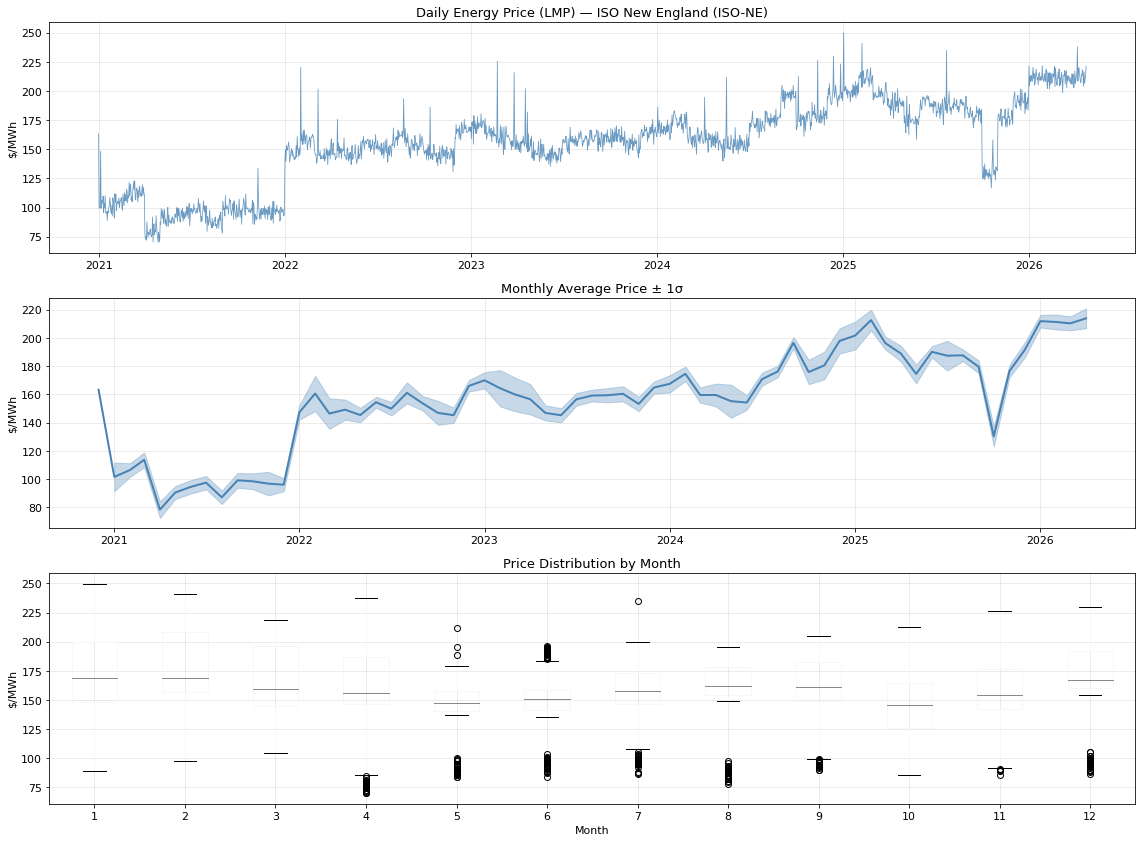

In [174]:
# ── 4a. Energy price history ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].plot(df["date"].values, df["lmp_price"].values, color="steelblue", lw=0.8, alpha=0.8)
axes[0].set_title(f"Daily Energy Price (LMP) — {REGION}", fontsize=13)
axes[0].set_ylabel("$/MWh")

# Monthly average with std band
monthly = df.groupby(df["date"].dt.to_period("M"))["lmp_price"].agg(["mean", "std"])
monthly.index = monthly.index.to_timestamp()
axes[1].fill_between(monthly.index.values,
                     (monthly["mean"] - monthly["std"]).values,
                     (monthly["mean"] + monthly["std"]).values, alpha=0.3, color="steelblue")
axes[1].plot(monthly.index.values, monthly["mean"].values, color="steelblue", lw=2)
axes[1].set_title("Monthly Average Price ± 1σ", fontsize=13)
axes[1].set_ylabel("$/MWh")

# Box plot by month
df.boxplot(column="lmp_price", by="month", ax=axes[2])
axes[2].set_title("Price Distribution by Month", fontsize=13)
axes[2].set_xlabel("Month"); axes[2].set_ylabel("$/MWh")
plt.suptitle("")
plt.tight_layout()
plt.show()


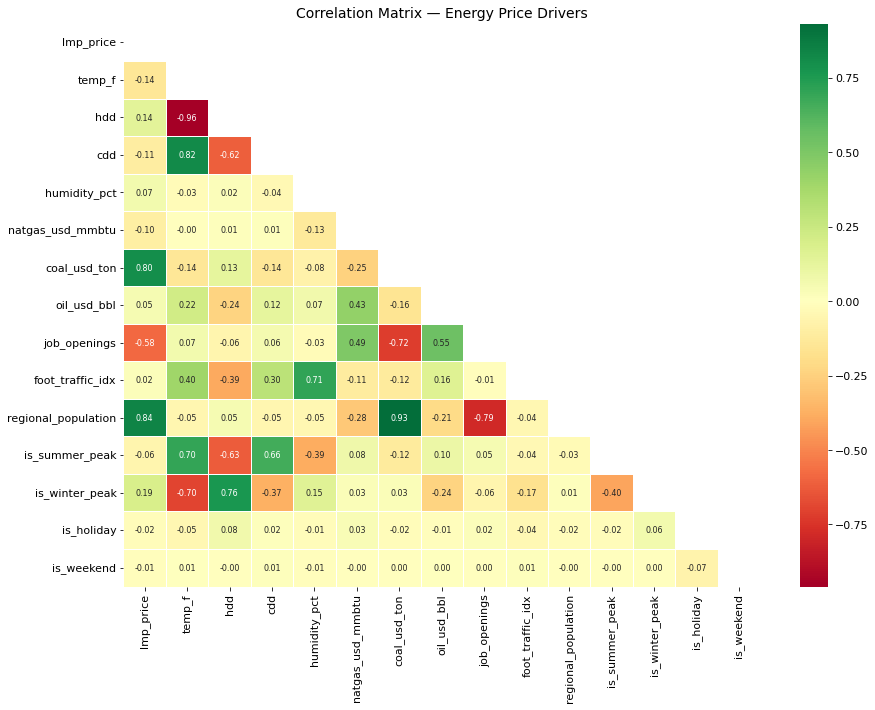

In [175]:
# ── 4b. Correlation heatmap ───────────────────────────────────────────────
eda_cols = ["lmp_price", "temp_f", "hdd", "cdd", "humidity_pct",
            "natgas_usd_mmbtu", "coal_usd_ton", "oil_usd_bbl",
            "job_openings", "foot_traffic_idx", "regional_population",
            "is_summer_peak", "is_winter_peak", "is_holiday", "is_weekend"]

corr = df[eda_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlation Matrix — Energy Price Drivers", fontsize=14)
plt.tight_layout()
plt.show()

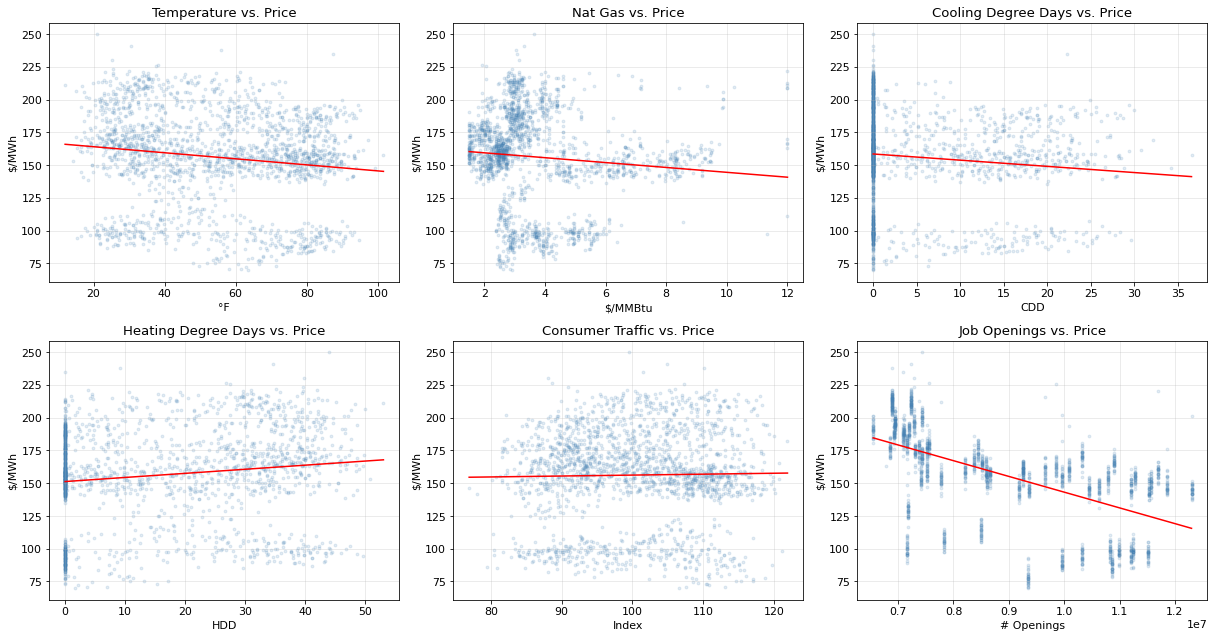

In [176]:
# ── 4c. Key driver scatter plots ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
scatter_pairs = [
    ("temp_f",              "°F",           "Temperature vs. Price"),
    ("natgas_usd_mmbtu",    "$/MMBtu",      "Nat Gas vs. Price"),
    ("cdd",                 "CDD",          "Cooling Degree Days vs. Price"),
    ("hdd",                 "HDD",          "Heating Degree Days vs. Price"),
    ("foot_traffic_idx",    "Index",        "Consumer Traffic vs. Price"),
    ("job_openings",        "# Openings",  "Job Openings vs. Price"),
]
for ax, (xcol, xlab, title) in zip(axes.flat, scatter_pairs):
    ax.scatter(df[xcol], df["lmp_price"], alpha=0.15, s=8, color="steelblue")
    z = np.polyfit(df[xcol], df["lmp_price"], 1)
    p = np.poly1d(z)
    xs = np.linspace(df[xcol].min(), df[xcol].max(), 200)
    ax.plot(xs, p(xs), "r-", lw=1.5)
    ax.set_xlabel(xlab); ax.set_ylabel("$/MWh"); ax.set_title(title)
plt.tight_layout()
plt.show()

## Section 5 — Time Series Decomposition of Energy Prices

STL (Seasonal-Trend decomposition using LOESS) separates the price signal into **trend**, **seasonality**, and **residual** components. The Augmented Dickey-Fuller test checks for stationarity:

$$\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^{p} \delta_i \,\Delta y_{t-i} + \epsilon_t$$

$H_0$: unit root present (non-stationary). Reject $H_0$ if $p < 0.05$.

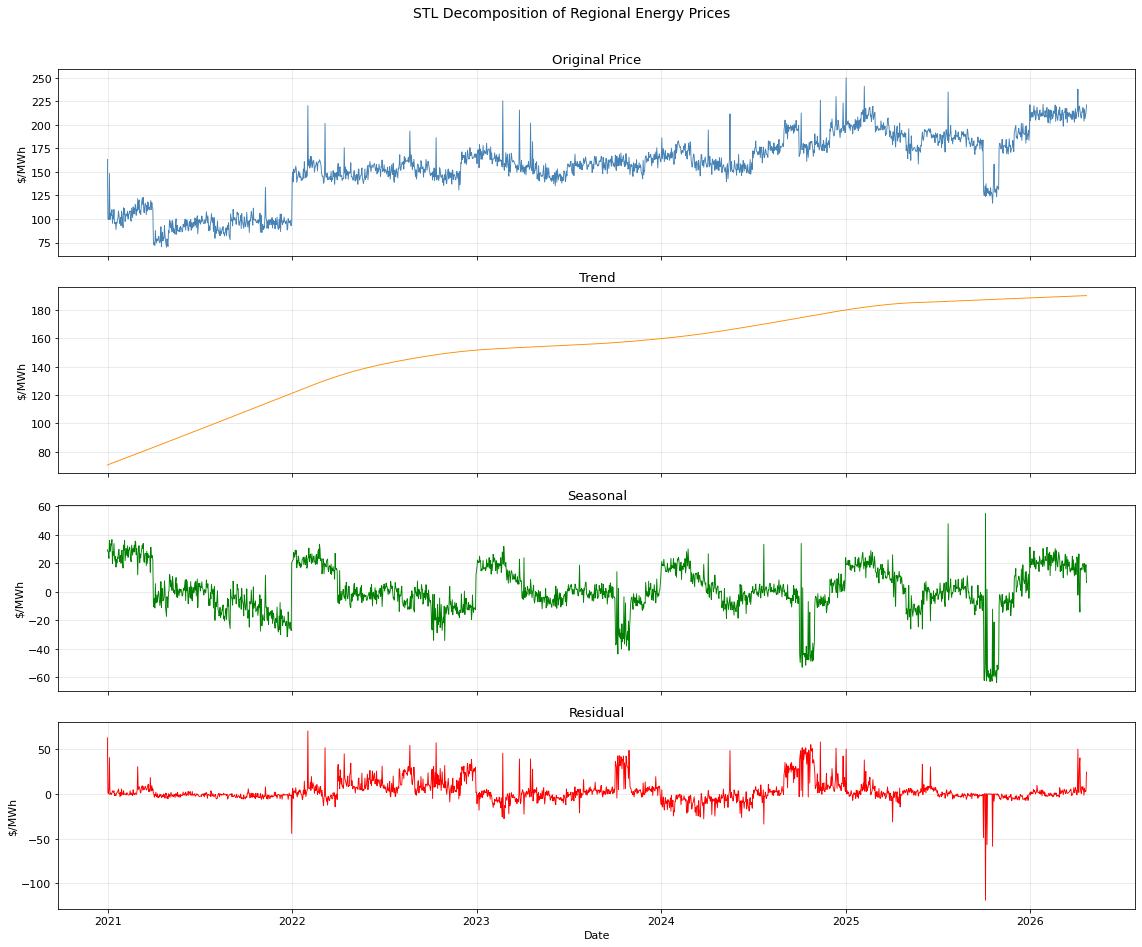


── Augmented Dickey-Fuller Test ──────────────────────────────
  ADF Statistic : -1.6689
  p-value       : 0.4472
  Critical (1%): -3.4337
  Critical (5%): -2.8630
  Critical (10%): -2.5676

  Conclusion: ⚠️  Non-stationary (fail to reject H₀)

  Residual std as % of total std: 35.1%


In [177]:
# ── STL decomposition ─────────────────────────────────────────────────────
price_series = df.set_index("date")["lmp_price"]
stl = STL(price_series, period=365, robust=True)
res = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 13), sharex=True)
components = [
    (price_series, "Original Price",  "steelblue"),
    (res.trend,    "Trend",           "darkorange"),
    (res.seasonal, "Seasonal",        "green"),
    (res.resid,    "Residual",        "red"),
]
for ax, (data, label, color) in zip(axes, components):
    ax.plot(data.index.values, data.values, color=color, lw=0.9)
    ax.set_ylabel("$/MWh")
    ax.set_title(label)
axes[-1].set_xlabel("Date")
plt.suptitle("STL Decomposition of Regional Energy Prices", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── ADF stationarity test ─────────────────────────────────────────────────
adf_result = adfuller(price_series.dropna())
print("\n── Augmented Dickey-Fuller Test ──────────────────────────────")
print(f"  ADF Statistic : {adf_result[0]:.4f}")
print(f"  p-value       : {adf_result[1]:.4f}")
for key, val in adf_result[4].items():
    print(f"  Critical ({key}): {val:.4f}")
conclusion = "✅ Stationary (reject H₀)" if adf_result[1] < 0.05 else "⚠️  Non-stationary (fail to reject H₀)"
print(f"\n  Conclusion: {conclusion}")

# Store residual variance ratio for model evaluation context
residual_pct = (res.resid.std() / price_series.std()) * 100
print(f"\n  Residual std as % of total std: {residual_pct:.1f}%")


## Section 6 — Baseline Forecasting Model (Prophet)

Facebook Prophet handles yearly and weekly seasonality natively and is robust to missing data and outliers. This serves as the baseline against which the advanced ML model is benchmarked.

06:56:27 - cmdstanpy - INFO - Chain [1] start processing
06:56:28 - cmdstanpy - INFO - Chain [1] done processing


── Prophet Baseline (90-day holdout) ──
  MAE  : $20.17/MWh
  RMSE : $22.83/MWh
  MAPE : 9.46%


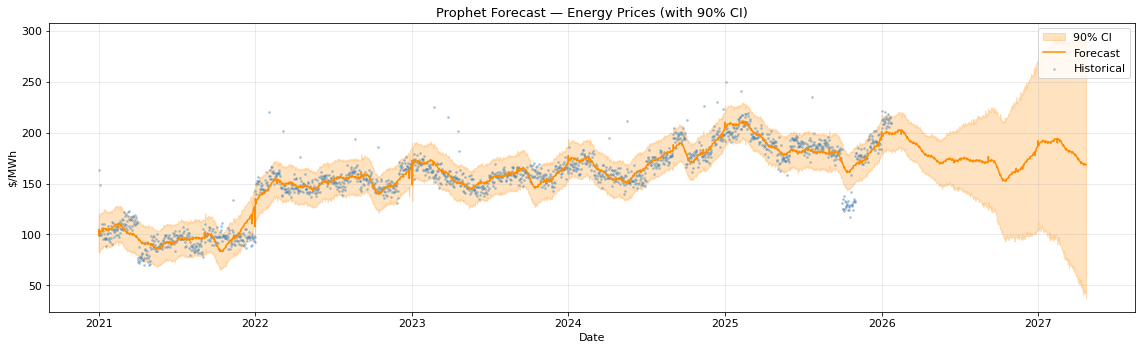

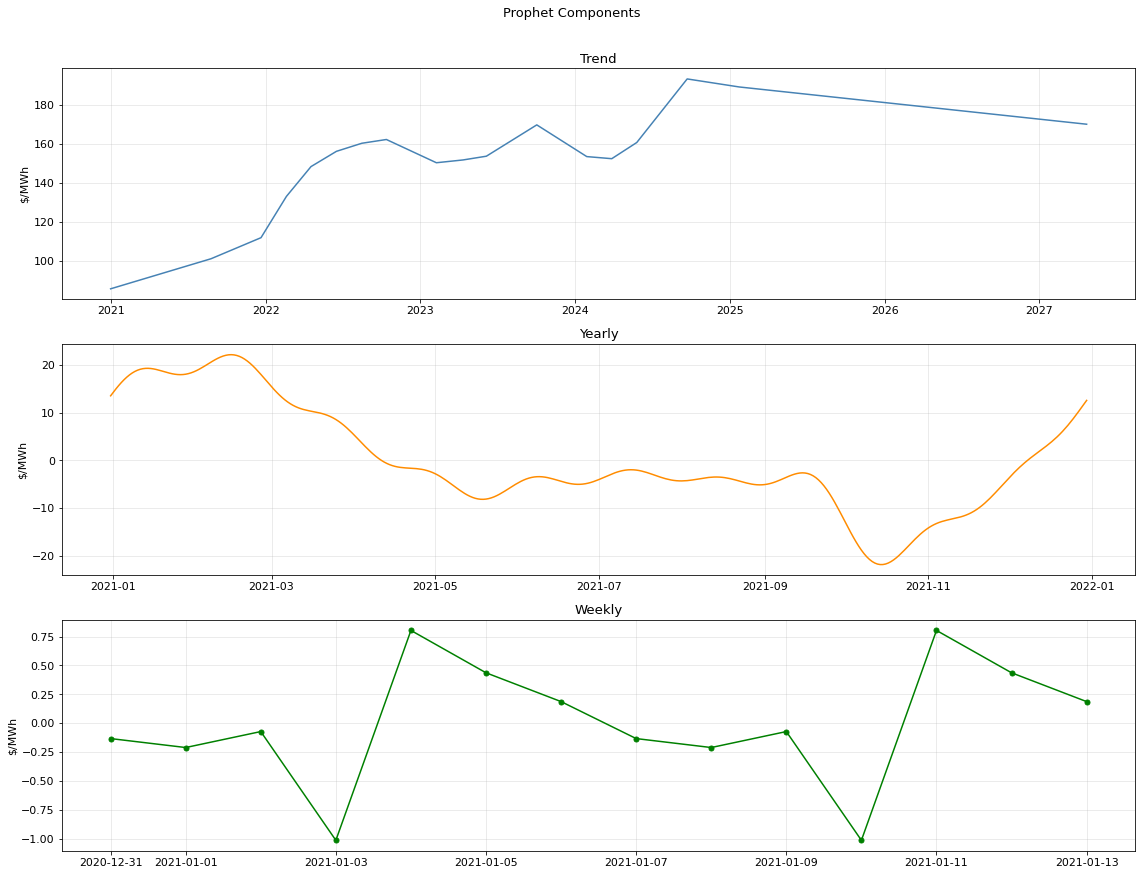

In [178]:
from prophet import Prophet

# ── Prepare Prophet dataframe ─────────────────────────────────────────────
prophet_df = df[["date", "lmp_price"]].rename(columns={"date": "ds", "lmp_price": "y"})

# Train / validation split — last 90 days as holdout
HOLDOUT_DAYS = 90
train_p = prophet_df.iloc[:-HOLDOUT_DAYS]
test_p  = prophet_df.iloc[-HOLDOUT_DAYS:]

# ── Fit Prophet model ──────────────────────────────────────────────────────
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.15,
    seasonality_prior_scale=12,
    interval_width=0.90,
)
model_prophet.add_country_holidays(country_name="US")
model_prophet.fit(train_p)

# ── Forecast ──────────────────────────────────────────────────────────────
future = model_prophet.make_future_dataframe(periods=HOLDOUT_DAYS + 365)
forecast_prophet = model_prophet.predict(future)

# ── Evaluate on holdout ───────────────────────────────────────────────────
pred_vals  = forecast_prophet.set_index("ds")["yhat"].reindex(test_p["ds"].values).values
actual_vals = test_p["y"].values

mae_p  = mean_absolute_error(actual_vals, pred_vals)
rmse_p = mean_squared_error(actual_vals, pred_vals) ** 0.5
mape_p = np.mean(np.abs((actual_vals - pred_vals) / actual_vals)) * 100

print(f"── Prophet Baseline (90-day holdout) ──")
print(f"  MAE  : ${mae_p:.2f}/MWh")
print(f"  RMSE : ${rmse_p:.2f}/MWh")
print(f"  MAPE : {mape_p:.2f}%")

# ── Main forecast plot (manual — avoids Prophet/matplotlib datetime conflict) ──
ds_vals      = forecast_prophet["ds"].values
yhat_vals    = forecast_prophet["yhat"].values
yhat_lo_vals = forecast_prophet["yhat_lower"].values
yhat_hi_vals = forecast_prophet["yhat_upper"].values

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(ds_vals, yhat_lo_vals, yhat_hi_vals,
                alpha=0.25, color="darkorange", label="90% CI")
ax.plot(ds_vals, yhat_vals, color="darkorange", lw=1.5, label="Forecast")
ax.scatter(train_p["ds"].values, train_p["y"].values,
           color="steelblue", s=3, alpha=0.35, label="Historical")
ax.set_title("Prophet Forecast — Energy Prices (with 90% CI)", fontsize=13)
ax.set_xlabel("Date"); ax.set_ylabel("$/MWh")
ax.legend(); plt.tight_layout(); plt.show()

# ── Components plot (manual) ──────────────────────────────────────────────
comp_cols = [c for c in ["trend", "yearly", "weekly"] if c in forecast_prophet.columns]
fig2, axes2 = plt.subplots(len(comp_cols), 1, figsize=(16, 4 * len(comp_cols)), sharex=False)
if len(comp_cols) == 1:
    axes2 = [axes2]

colors_map = {"trend": "steelblue", "yearly": "darkorange", "weekly": "green"}
for ax2, comp in zip(axes2, comp_cols):
    if comp == "weekly":
        # Show one clean 7-day cycle
        subset = forecast_prophet.head(14)
        ax2.plot(subset["ds"].values, subset[comp].values,
                 color=colors_map[comp], lw=1.5, marker="o", ms=5)
    elif comp == "yearly":
        # Show one year cycle
        subset = forecast_prophet.head(365)
        ax2.plot(subset["ds"].values, subset[comp].values,
                 color=colors_map[comp], lw=1.5)
    else:
        ax2.plot(ds_vals, forecast_prophet[comp].values,
                 color=colors_map[comp], lw=1.5)
    ax2.set_title(comp.capitalize()); ax2.set_ylabel("$/MWh")

plt.suptitle("Prophet Components", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## Section 7 — Advanced ML Forecasting Model (XGBoost + SHAP)

XGBoost is trained on the full engineered feature set. SHAP (SHapley Additive exPlanations) is used to explain model predictions and rank feature importance.

$$MAPE = \frac{1}{n}\sum_{t=1}^{n}\left|\frac{y_t - \hat{y}_t}{y_t}\right| \times 100$$

── XGBoost Model Performance (holdout) ──
  MAE  : $9.52/MWh  (Prophet baseline: $20.17)
  RMSE : $12.14/MWh  (Prophet baseline: $22.83)
  MAPE : 4.45%       (Prophet baseline: 9.46%)


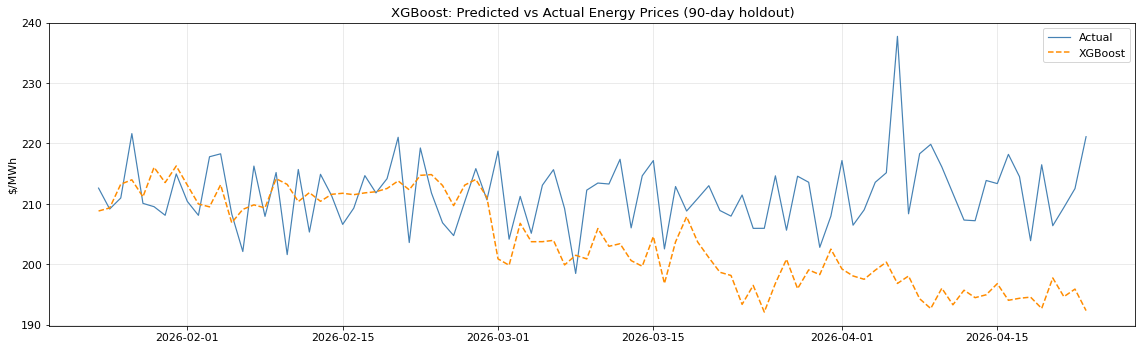

In [179]:
# ── Feature selection ─────────────────────────────────────────────────────
exclude = ["date", "lmp_price", "lmp_price_clipped"]
feature_cols = [c for c in df.columns if c not in exclude]

X = df[feature_cols].values
y = df["lmp_price"].values

# ── Time-series cross-validation split ───────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5, test_size=HOLDOUT_DAYS)
split_idx = list(tscv.split(X))
train_idx, test_idx = split_idx[-1]   # Use last fold as primary eval

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
dates_test = df["date"].values[test_idx]

# ── XGBoost model ─────────────────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb) ** 0.5
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100

print("── XGBoost Model Performance (holdout) ──")
print(f"  MAE  : ${mae_xgb:.2f}/MWh  (Prophet baseline: ${mae_p:.2f})")
print(f"  RMSE : ${rmse_xgb:.2f}/MWh  (Prophet baseline: ${rmse_p:.2f})")
print(f"  MAPE : {mape_xgb:.2f}%       (Prophet baseline: {mape_p:.2f}%)")

# ── Actual vs Predicted plot ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(dates_test, y_test,     label="Actual",    color="steelblue", lw=1.2)
ax.plot(dates_test, y_pred_xgb, label="XGBoost",   color="darkorange", lw=1.5, linestyle="--")
ax.set_title("XGBoost: Predicted vs Actual Energy Prices (90-day holdout)")
ax.set_ylabel("$/MWh"); ax.legend(); plt.tight_layout(); plt.show()

✅  XGBoost 2.1.4 is compatible with SHAP.


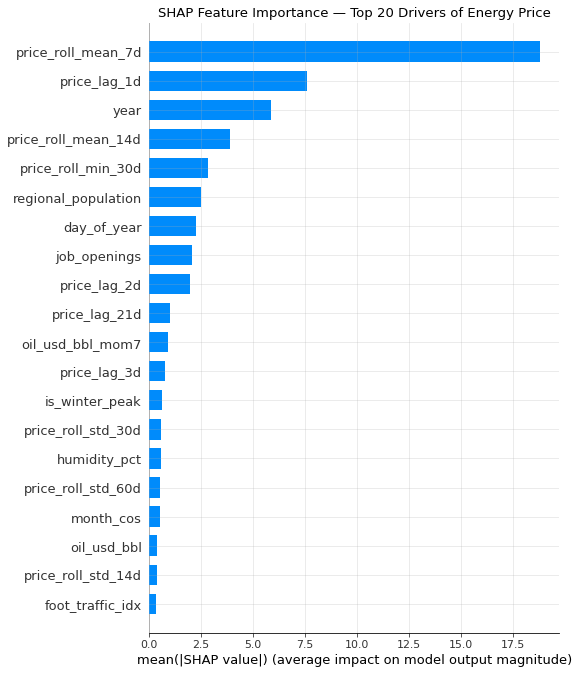

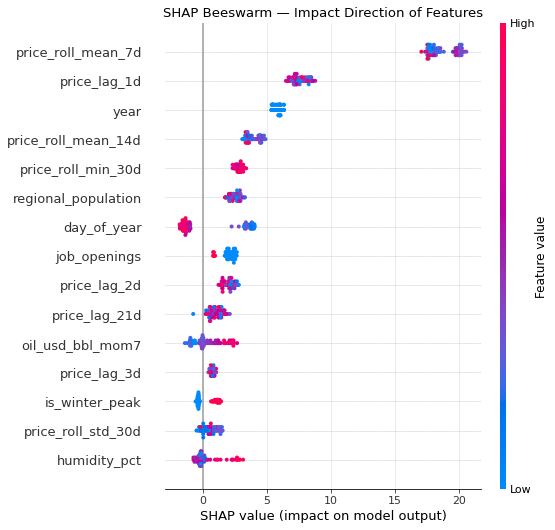

In [180]:
# ── Ensure XGBoost 1.6–2.x is active (SHAP 0.49.x incompatible with XGBoost 3.x) ──
import sys, site

# Ensure user site-packages (has xgboost 2.1.4) is checked before system packages
_user_site = site.getusersitepackages()
if _user_site not in sys.path:
    sys.path.insert(0, _user_site)

_xgb_ver = tuple(int(x) for x in xgb.__version__.split(".")[:2])
if _xgb_ver < (1, 6) or _xgb_ver >= (3, 0):
    print(f"⚠️  Kernel has XGBoost {xgb.__version__} — reloading compatible version...")
    for _k in [k for k in sys.modules if k == "xgboost" or k.startswith("xgboost.")]:
        del sys.modules[_k]
    import xgboost as xgb
    # Re-fit with freshly-imported xgboost (same params + seed → deterministic)
    xgb_model = xgb.XGBRegressor(
        n_estimators=800, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        reg_alpha=0.1, reg_lambda=1.5, random_state=42, n_jobs=-1, verbosity=0,
    )
    xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    y_pred_xgb = xgb_model.predict(X_test)
    print(f"✅  XGBoost {xgb.__version__} loaded, model re-fitted.")
else:
    print(f"✅  XGBoost {xgb.__version__} is compatible with SHAP.")

# ── SHAP Feature Importance ────────────────────────────────────────────────
explainer  = shap.TreeExplainer(xgb_model)
shap_vals  = explainer.shap_values(X_test[:300])   # subset for speed

shap.summary_plot(shap_vals, X_test[:300], feature_names=feature_cols,
                  plot_type="bar", show=False, max_display=20)
plt.title("SHAP Feature Importance — Top 20 Drivers of Energy Price")
plt.tight_layout(); plt.show()

shap.summary_plot(shap_vals, X_test[:300], feature_names=feature_cols,
                  show=False, max_display=15)
plt.title("SHAP Beeswarm — Impact Direction of Features")
plt.tight_layout(); plt.show()


In [181]:
# ── Forward 365-day forecast (rolling re-prediction using last known features) ──
last_row = df.iloc[-1].copy()
future_dates = pd.date_range(df["date"].max() + pd.Timedelta("1D"), periods=365, freq="D")

forward_rows = []
rolling_prices = list(df["lmp_price"].values[-60:])   # seed for lag features

for fd in future_dates:
    row = last_row.copy()
    row["date"] = fd
    # Update cyclical features
    doy = fd.dayofyear
    m   = fd.month
    dow = fd.dayofweek
    row["day_of_year"] = doy;  row["month"] = m;  row["day_of_week"] = dow
    row["week_of_year"] = fd.isocalendar()[1]; row["year"] = fd.year; row["quarter"] = fd.quarter
    row["day_of_year_sin"] = np.sin(2*np.pi*doy/365); row["day_of_year_cos"] = np.cos(2*np.pi*doy/365)
    row["month_sin"] = np.sin(2*np.pi*m/12);  row["month_cos"] = np.cos(2*np.pi*m/12)
    row["day_of_week_sin"] = np.sin(2*np.pi*dow/7); row["day_of_week_cos"] = np.cos(2*np.pi*dow/7)
    row["is_holiday"] = int(fd in us_holidays); row["is_weekend"] = int(dow >= 5)
    row["is_summer_peak"] = int(6 <= m <= 9); row["is_winter_peak"] = int(m == 12 or m <= 2)
    # Lag features from rolling history
    for lag in [1, 2, 3, 7, 14, 21, 30]:
        row[f"price_lag_{lag}d"] = rolling_prices[-lag] if len(rolling_prices) >= lag else np.mean(rolling_prices)
    for window in [7, 14, 30, 60]:
        w = rolling_prices[-window:] if len(rolling_prices) >= window else rolling_prices
        row[f"price_roll_mean_{window}d"] = np.mean(w)
        row[f"price_roll_std_{window}d"]  = np.std(w)
    row["price_roll_max_30d"] = max(rolling_prices[-30:]) if len(rolling_prices) >= 30 else max(rolling_prices)
    row["price_roll_min_30d"] = min(rolling_prices[-30:]) if len(rolling_prices) >= 30 else min(rolling_prices)
    forward_rows.append(row)

df_future = pd.DataFrame(forward_rows)
X_future  = df_future[feature_cols].values.astype(float)
y_future  = xgb_model.predict(X_future)
df_future["predicted_price"] = y_future

# Update rolling buffer with predicted values
rolling_prices.extend(y_future.tolist())

print(f"✅ 365-day forward forecast generated:  {future_dates[0].date()} → {future_dates[-1].date()}")
print(f"   Predicted mean: ${y_future.mean():.2f}/MWh  |  Max: ${y_future.max():.2f}  |  Min: ${y_future.min():.2f}")

✅ 365-day forward forecast generated:  2026-04-24 → 2027-04-23
   Predicted mean: $194.50/MWh  |  Max: $207.34  |  Min: $185.61


## Section 8 — Peak Price Period Detection

Identify projected peak price windows using both **percentile thresholds** (top 10%) and **z-score anomaly detection**. These windows drive the shutdown scheduling and reserve strategy in later sections.

Peak threshold   (P90):    $205.57/MWh  →  37 peak days
Extreme threshold (P97): $206.29/MWh  →  11 extreme days
Profit-sell threshold ($200/MWh):  →  59 days above threshold


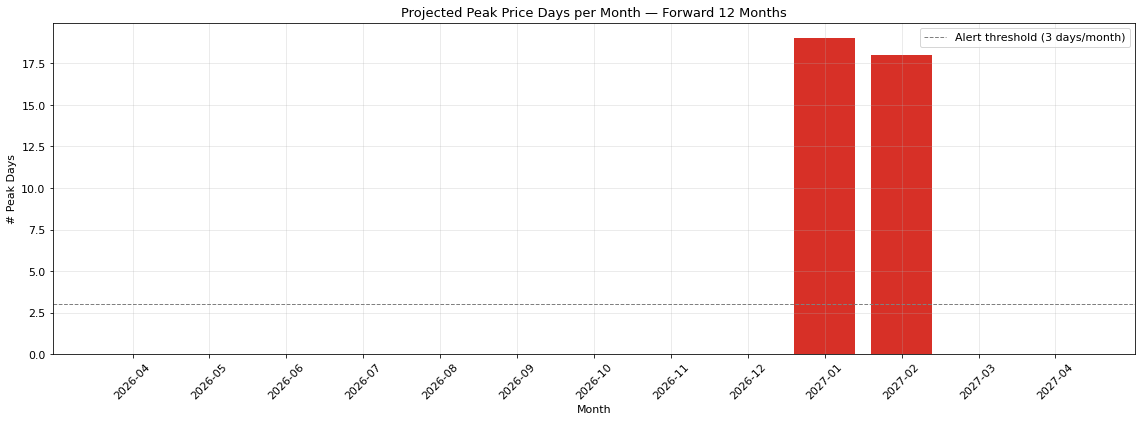

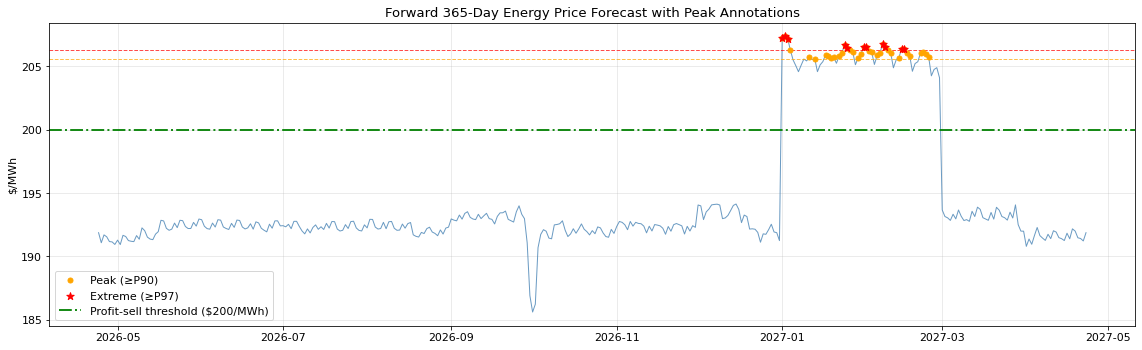

In [182]:
# ── Peak thresholds ───────────────────────────────────────────────────────
PEAK_PERCENTILE   = 90     # Top 10% of predicted prices
EXTREME_PERCENTILE = 97    # Top 3% — "extreme" events

p90 = np.percentile(df_future["predicted_price"], PEAK_PERCENTILE)
p97 = np.percentile(df_future["predicted_price"], EXTREME_PERCENTILE)
z_scores = stats.zscore(df_future["predicted_price"])

df_future["is_peak"]    = (df_future["predicted_price"] >= p90).astype(int)
df_future["is_extreme"] = (df_future["predicted_price"] >= p97).astype(int)
df_future["zscore"]     = z_scores

# ── Profit-sell threshold flag ─────────────────────────────────────────────
df_future["above_profit_threshold"] = (
    df_future["predicted_price"] >= PROFIT_THRESHOLD_MWH
).astype(int)
n_above_threshold = int(df_future["above_profit_threshold"].sum())

print(f"Peak threshold   (P{PEAK_PERCENTILE}):    ${p90:.2f}/MWh  →  {df_future['is_peak'].sum()} peak days")
print(f"Extreme threshold (P{EXTREME_PERCENTILE}): ${p97:.2f}/MWh  →  {df_future['is_extreme'].sum()} extreme days")
print(f"Profit-sell threshold (${PROFIT_THRESHOLD_MWH}/MWh):  →  {n_above_threshold} days above threshold")

# ── Calendar heatmap of predicted prices ──────────────────────────────────
df_cal = df_future.copy()
df_cal["week"] = df_cal["date"].apply(lambda d: d.isocalendar()[1])
df_cal["month_name"] = df_cal["date"].dt.strftime("%b")
df_cal["day_name"]   = df_cal["date"].dt.strftime("%a")
df_cal["day_num"]    = df_cal["date"].dt.day

pivot_monthly = (
    df_cal.groupby([df_cal["date"].dt.strftime("%Y-%m"), "is_peak"])
    .size().unstack(fill_value=0)
    .rename(columns={0: "Normal Days", 1: "Peak Days"})
)

fig, ax = plt.subplots(figsize=(16, 6))
months_list = df_cal["date"].dt.to_period("M").unique()
peak_counts = [df_cal[df_cal["date"].dt.to_period("M") == m]["is_peak"].sum() for m in months_list]
colors = ["#d73027" if c >= 5 else "#fee08b" if c >= 2 else "#91bfdb" for c in peak_counts]
ax.bar([str(m) for m in months_list], peak_counts, color=colors)
ax.axhline(y=3, color="gray", linestyle="--", lw=1, label="Alert threshold (3 days/month)")
ax.set_title("Projected Peak Price Days per Month — Forward 12 Months", fontsize=13)
ax.set_xlabel("Month"); ax.set_ylabel("# Peak Days")
ax.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# ── Timeline with peak annotations ───────────────────────────────────────
peak_days    = df_future[df_future["is_peak"] == 1]
extreme_days = df_future[df_future["is_extreme"] == 1]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_future["date"].values, df_future["predicted_price"].values,
        color="steelblue", lw=1, alpha=0.8)
ax.scatter(peak_days["date"].values,    peak_days["predicted_price"].values,
           color="orange", s=25, zorder=3, label=f"Peak (≥P{PEAK_PERCENTILE})")
ax.scatter(extreme_days["date"].values, extreme_days["predicted_price"].values,
           color="red", s=60, zorder=4, marker="*", label=f"Extreme (≥P{EXTREME_PERCENTILE})")
ax.axhline(p90, color="orange", linestyle="--", lw=1, alpha=0.7)
ax.axhline(p97, color="red",    linestyle="--", lw=1, alpha=0.7)
ax.axhline(PROFIT_THRESHOLD_MWH, color="green", linestyle="-.", lw=2, alpha=0.9,
           label=f"Profit-sell threshold (${PROFIT_THRESHOLD_MWH}/MWh)")
ax.set_title("Forward 365-Day Energy Price Forecast with Peak Annotations")
ax.set_ylabel("$/MWh"); ax.legend(); plt.tight_layout(); plt.show()

  PROFIT THRESHOLD EXCEEDANCE ANALYSIS
  Threshold : $200/MWh  (edit PROFIT_THRESHOLD_MWH in config to match your margin)

  ⚠️  59 days (16.2% of forecast) exceed $200/MWh
  Avg price on those days : $205.73/MWh
  Peak price on those days: $207.34/MWh

  Month-by-Month Exceedance:
  Month        Days     Avg $/MWh     Max $/MWh
  ----------  -----  ------------  ------------
  2027-01        31  $    205.79   $    207.34
  2027-02        28  $    205.67   $    206.74

  WHY PRICES EXCEED $200/MWh — Top SHAP Drivers
  (XGBoost explanation for the 59 above-threshold forecast days)
  Factor                                                Impact  Direction
  --------------------------------------------------  --------  ----------------------
  Sustained recent price momentum (7-day avg)         $ 19.94   ↑ pushing price UP
  Previous-day price carry-over                       $  7.17   ↑ pushing price UP
  Multi-year upward price trend                       $  6.01   ↑ pushing price UP
  T

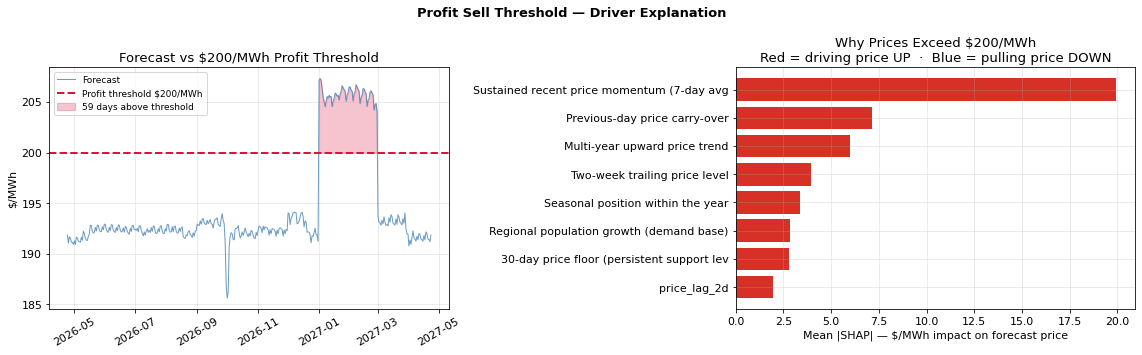

In [183]:
# ── Profit Threshold Exceedance Analysis ─────────────────────────────────
# Identifies which forecast days exceed PROFIT_THRESHOLD_MWH and uses SHAP
# values computed on the forward-forecast feature matrix (X_future) to explain
# *why* the model expects prices to be that high on those specific days.

above_mask = df_future["above_profit_threshold"] == 1
n_above    = int(above_mask.sum())
pct_above  = n_above / len(df_future) * 100

print("=" * 62)
print(f"  PROFIT THRESHOLD EXCEEDANCE ANALYSIS")
print(f"  Threshold : ${PROFIT_THRESHOLD_MWH:.0f}/MWh  "
      f"(edit PROFIT_THRESHOLD_MWH in config to match your margin)")
print("=" * 62)

if n_above == 0:
    print(f"\n  ✅ Forecast stays BELOW ${PROFIT_THRESHOLD_MWH:.0f}/MWh "
          f"for the full 365-day window.")
    print(f"     Running production at full capacity is optimal throughout.")
else:
    above_df = df_future[above_mask].copy()
    print(f"\n  ⚠️  {n_above} days ({pct_above:.1f}% of forecast) "
          f"exceed ${PROFIT_THRESHOLD_MWH:.0f}/MWh")
    print(f"  Avg price on those days : ${above_df['predicted_price'].mean():.2f}/MWh")
    print(f"  Peak price on those days: ${above_df['predicted_price'].max():.2f}/MWh")

    # ── Month-by-month breakdown ────────────────────────────────────────
    monthly_thr = (
        above_df
        .groupby(above_df["date"].dt.to_period("M"))
        .agg(days=("predicted_price", "count"),
             avg_price=("predicted_price", "mean"),
             max_price=("predicted_price", "max"))
        .reset_index()
        .rename(columns={"date": "month"})
    )
    print(f"\n  Month-by-Month Exceedance:")
    print(f"  {'Month':<10s}  {'Days':>5s}  {'Avg $/MWh':>12s}  {'Max $/MWh':>12s}")
    print(f"  {'-'*10}  {'-'*5}  {'-'*12}  {'-'*12}")
    for _, r in monthly_thr.iterrows():
        print(f"  {str(r['month']):<10s}  {int(r['days']):>5d}  "
              f"${r['avg_price']:>10.2f}   ${r['max_price']:>10.2f}")

    # ── SHAP values for above-threshold days ────────────────────────────
    # Use numpy positional indexing (X_future is 365-row array, 0-based)
    above_positions = np.where(above_mask.values)[0]   # 0-based row positions in X_future
    X_above         = X_future[above_positions]
    shap_above      = explainer.shap_values(X_above)   # (n_above, n_features)

    mean_abs_shap  = pd.Series(np.abs(shap_above).mean(axis=0), index=feature_cols)
    mean_sign_shap = pd.Series(shap_above.mean(axis=0),         index=feature_cols)
    top_feats      = mean_abs_shap.nlargest(8)

    # Plain-English driver labels
    _driver_labels = {
        "price_roll_mean_7d"  : "Sustained recent price momentum (7-day avg)",
        "price_lag_1d"        : "Previous-day price carry-over",
        "price_roll_mean_14d" : "Two-week trailing price level",
        "price_roll_mean_30d" : "Monthly trailing price level",
        "price_roll_min_30d"  : "30-day price floor (persistent support level)",
        "price_roll_max_30d"  : "30-day price ceiling (recent high episode)",
        "year"                : "Multi-year upward price trend",
        "day_of_year"         : "Seasonal position within the year",
        "is_winter_peak"      : "Winter seasonal demand surge (Dec–Feb)",
        "is_summer_peak"      : "Summer cooling demand surge (Jun–Sep)",
        "job_openings"        : "Tight labour market (high industrial activity)",
        "oil_usd_bbl_mom7"   : "Rising oil / commodity prices",
        "gas_usd_mmbtu_mom7" : "Rising natural gas prices",
        "regional_population" : "Regional population growth (demand base)",
    }

    print(f"\n  WHY PRICES EXCEED ${PROFIT_THRESHOLD_MWH:.0f}/MWh — Top SHAP Drivers")
    print(f"  (XGBoost explanation for the {n_above} above-threshold forecast days)")
    print(f"  {'Factor':<50s}  {'Impact':>8s}  Direction")
    print(f"  {'-'*50}  {'-'*8}  {'-'*22}")
    for feat, impact in top_feats.items():
        direction = "↑ pushing price UP" if mean_sign_shap[feat] > 0 else "↓ pulling price DOWN"
        label     = _driver_labels.get(feat, feat)
        print(f"  {label:<50s}  ${impact:>6.2f}   {direction}")

    # ── Visualisation ──────────────────────────────────────────────────
    fig, axes_thr = plt.subplots(1, 2, figsize=(16, 5))

    # Left: forecast timeline with threshold shading
    axes_thr[0].plot(df_future["date"].values,
                     df_future["predicted_price"].values,
                     color="steelblue", lw=1, alpha=0.8, label="Forecast")
    axes_thr[0].axhline(PROFIT_THRESHOLD_MWH, color="crimson", lw=2,
                        linestyle="--",
                        label=f"Profit threshold ${PROFIT_THRESHOLD_MWH:.0f}/MWh")
    axes_thr[0].fill_between(
        df_future["date"].values,
        PROFIT_THRESHOLD_MWH, df_future["predicted_price"].values,
        where=(df_future["predicted_price"].values > PROFIT_THRESHOLD_MWH),
        alpha=0.25, color="crimson",
        label=f"{n_above} days above threshold",
    )
    axes_thr[0].set_title(f"Forecast vs ${PROFIT_THRESHOLD_MWH:.0f}/MWh Profit Threshold")
    axes_thr[0].set_ylabel("$/MWh")
    axes_thr[0].legend(fontsize=9)
    axes_thr[0].tick_params(axis="x", rotation=30)

    # Right: SHAP bar chart — top drivers for above-threshold days
    bar_colors   = ["#d73027" if mean_sign_shap[f] > 0 else "#4575b4"
                    for f in top_feats.index]
    short_labels = [_driver_labels.get(f, f)[:42] for f in top_feats.index]
    axes_thr[1].barh(short_labels[::-1], top_feats.values[::-1],
                     color=bar_colors[::-1])
    axes_thr[1].set_xlabel("Mean |SHAP| — $/MWh impact on forecast price")
    axes_thr[1].set_title(
        f"Why Prices Exceed ${PROFIT_THRESHOLD_MWH:.0f}/MWh\n"
        "Red = driving price UP  ·  Blue = pulling price DOWN"
    )
    plt.suptitle("Profit Sell Threshold — Driver Explanation",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

print("=" * 62)

  ISO-NE CAPACITY PRICING & PEAK TAG RISK ANALYSIS

  YOUR CURRENT CAPACITY COST STRUCTURE
  ┌─ Capacity tag             : 85 MW  (100% of 85 MW — set by summer peak hour)
  ├─ FCM clearing price       : $3.58/kW-month  (ISO-NE FCA #17, 2026/2027)
  ├─ Annual capacity bill     : $   3,651,600/year
  ├─ Annual consumption       :      595,680 MWh/year
  ├─ Capacity adder           : $  6.13/MWh  (amortised over annual consumption)
  ├─ Transmission adder       : $  8.00/MWh
  └─ TOTAL non-energy adder   : $ 14.13/MWh

  ALL-IN EFFECTIVE ELECTRICITY COST (forecast period)
  ├─ Average all-in cost      : $208.63/MWh
  └─ Peak all-in cost         : $221.47/MWh

  THRESHOLD IMPLICATION
  ├─ PROFIT_THRESHOLD_MWH       = $200/MWh  (your input)
  ├─ Non-energy overhead        = $14.13/MWh
  └─ Equivalent energy-only BE  = $185.87/MWh
     (spot price at which all-in cost = your $200/MWh threshold)

  Days where all-in cost exceeds $200/MWh: 364 (vs 59 on spot price alone)

  CAPACITY OPTION VA

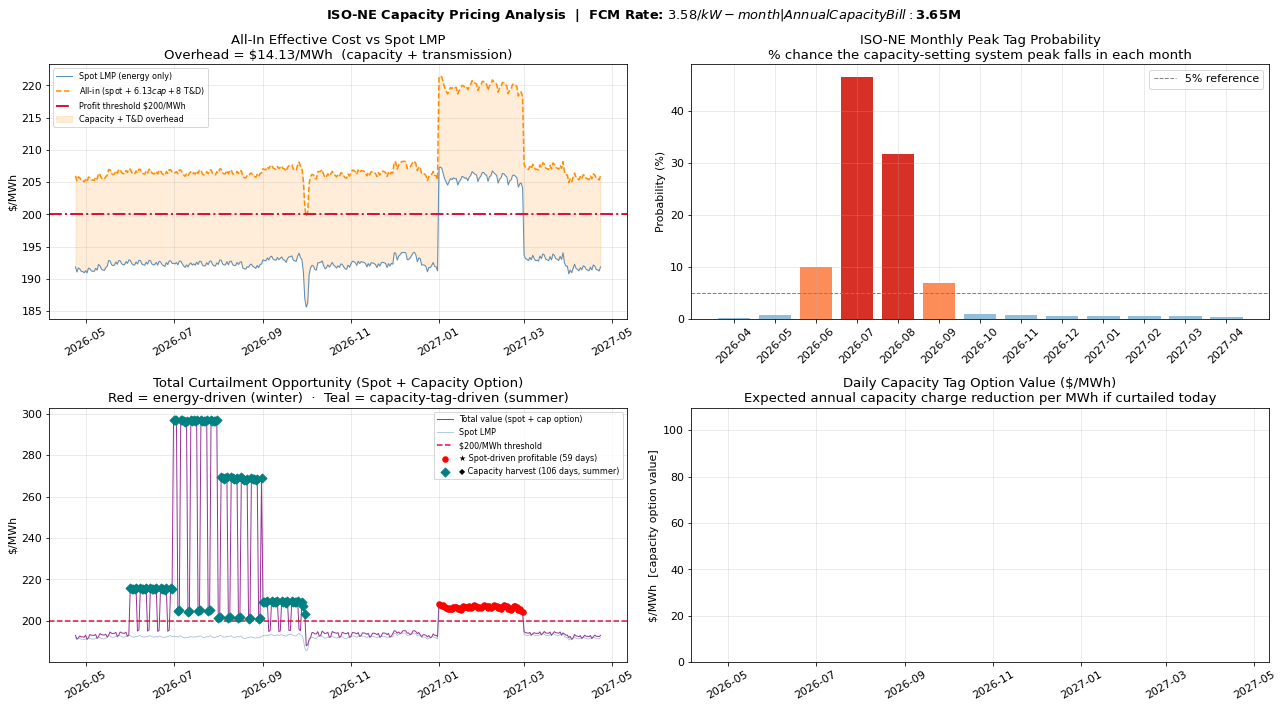

In [187]:
# ── ISO-NE Capacity Pricing & Peak Tag Analysis ───────────────────────────
#
# For ISO-NE industrial customers the electricity bill has three layers:
#   1. ENERGY (LMP spot)   — variable, already modeled in this notebook
#   2. CAPACITY (FCM)      — fixed annual bill driven by ONE summer peak hour
#   3. TRANSMISSION        — semi-fixed per-MWh adder (~$8/MWh)
#
# Spot price alone UNDERSTATES your true cost and misidentifies when to curtail.
# The ISO-NE system peak (the single hour that SETS your capacity tag for the
# entire coming year) typically falls on a hot July or August weekday afternoon.
# Curtailing during THOSE hours — even when spot prices are only $150/MWh —
# can eliminate millions of dollars in annual capacity charges.

print("=" * 68)
print("  ISO-NE CAPACITY PRICING & PEAK TAG RISK ANALYSIS")
print("=" * 68)

# ── All-in effective cost computation ─────────────────────────────────────
_tag_mw           = FACILITY_MW * CAPACITY_TAG_FRACTION        # MW "on" at system peak
_annual_cap_cost  = _tag_mw * 1_000 * CAPACITY_PRICE_KW_MONTH * 12   # $/yr total bill
_annual_mwh       = FACILITY_MW * 8_760 * ANNUAL_CAPACITY_FACTOR      # MWh/yr consumed
_cap_per_mwh      = _annual_cap_cost / _annual_mwh                    # amortised $/MWh

df_future["capacity_adder_mwh"]   = _cap_per_mwh
df_future["td_adder_mwh"]         = TRANSMISSION_ADDER_MWH
df_future["all_in_effective_mwh"] = (
    df_future["predicted_price"] + _cap_per_mwh + TRANSMISSION_ADDER_MWH
)

print(f"\n  YOUR CURRENT CAPACITY COST STRUCTURE")
print(f"  ┌─ Capacity tag             : {_tag_mw:.0f} MW  "
      f"({CAPACITY_TAG_FRACTION*100:.0f}% of {FACILITY_MW} MW — set by summer peak hour)")
print(f"  ├─ FCM clearing price       : ${CAPACITY_PRICE_KW_MONTH:.2f}/kW-month  (ISO-NE FCA #17, 2026/2027)")
print(f"  ├─ Annual capacity bill     : ${_annual_cap_cost:>12,.0f}/year")
print(f"  ├─ Annual consumption       : {_annual_mwh:>12,.0f} MWh/year")
print(f"  ├─ Capacity adder           : ${_cap_per_mwh:>6.2f}/MWh  (amortised over annual consumption)")
print(f"  ├─ Transmission adder       : ${TRANSMISSION_ADDER_MWH:>6.2f}/MWh")
print(f"  └─ TOTAL non-energy adder   : ${_cap_per_mwh + TRANSMISSION_ADDER_MWH:>6.2f}/MWh")

_avg_allin  = df_future["all_in_effective_mwh"].mean()
_max_allin  = df_future["all_in_effective_mwh"].max()
_equiv_spot = PROFIT_THRESHOLD_MWH - _cap_per_mwh - TRANSMISSION_ADDER_MWH

print(f"\n  ALL-IN EFFECTIVE ELECTRICITY COST (forecast period)")
print(f"  ├─ Average all-in cost      : ${_avg_allin:.2f}/MWh")
print(f"  └─ Peak all-in cost         : ${_max_allin:.2f}/MWh")
print(f"\n  THRESHOLD IMPLICATION")
print(f"  ├─ PROFIT_THRESHOLD_MWH       = ${PROFIT_THRESHOLD_MWH:.0f}/MWh  (your input)")
print(f"  ├─ Non-energy overhead        = ${_cap_per_mwh + TRANSMISSION_ADDER_MWH:.2f}/MWh")
print(f"  └─ Equivalent energy-only BE  = ${_equiv_spot:.2f}/MWh")
print(f"     (spot price at which all-in cost = your ${PROFIT_THRESHOLD_MWH:.0f}/MWh threshold)")

_n_above_allin = int((df_future["all_in_effective_mwh"] >= PROFIT_THRESHOLD_MWH).sum())
print(f"\n  Days where all-in cost exceeds ${PROFIT_THRESHOLD_MWH:.0f}/MWh: {_n_above_allin} "
      f"(vs {n_above_threshold} on spot price alone)")

# ── Peak tag probability model ─────────────────────────────────────────────
# P(this forecast day contains the ISO-NE annual system peak hour)
# Based on historical ISO-NE peak occurrence 2010-2024:
#   • ~80% of peaks fall in July or August
#   • Weekdays are almost exclusively the system peak (commercial AC load)
#   • ~10% fall in June or September; winter peaks are extremely rare in ISO-NE
_month_weight = {
    1: 0.005, 2: 0.005, 3: 0.005, 4: 0.005, 5: 0.008,
    6: 0.10,  7: 0.45,  8: 0.33,  9: 0.07,
    10: 0.01, 11: 0.007, 12: 0.005,
}
_raw_peak_prob = df_future.apply(
    lambda r: _month_weight.get(int(r["month"]), 0.005)
              * (0.12 if int(r["day_of_week"]) >= 5 else 1.0),
    axis=1,
)
# Normalise so probabilities sum to 1.0 across forecast window
# (exactly one system peak event per year — this is the 1CP model)
df_future["peak_tag_prob"] = _raw_peak_prob / _raw_peak_prob.sum()

# ── Capacity option value of curtailing today ──────────────────────────────
# If this day IS the annual system peak and you curtail FACILITY_MW for DR_HOURS:
#   → Your capacity tag drops from _tag_mw → 0 (or proportionally lower)
#   → You save _annual_cap_cost in charges for the entire coming year
# Expected value of this saving = P(today is peak) × _annual_cap_cost
# Expressed as $/MWh using the DR event curtailment volume:
_curtail_mwh_event = FACILITY_MW * DR_HOURS_PER_EVENT   # MWh curtailed per DR event
df_future["capacity_option_value_mwh"] = (
    df_future["peak_tag_prob"] * _annual_cap_cost / _curtail_mwh_event
)

# Total opportunity value = spot LMP + expected capacity savings from curtailing
df_future["total_curtail_value_mwh"] = (
    df_future["predicted_price"] + df_future["capacity_option_value_mwh"]
)

# "Capacity harvest" days: spot below threshold BUT total opportunity above it
# → curtailment is worthwhile purely due to peak tag risk, not spot prices
df_future["capacity_harvest_day"] = (
    (df_future["predicted_price"] < PROFIT_THRESHOLD_MWH)
    & (df_future["total_curtail_value_mwh"] >= PROFIT_THRESHOLD_MWH)
).astype(int)

_n_capacity_harvest = int(df_future["capacity_harvest_day"].sum())
# Use values.argmax() to avoid the duplicate-index problem (df_future inherits df's index)
_top_cap_pos     = int(np.argmax(df_future["peak_tag_prob"].values))
_top_cap_day_row = df_future.iloc[_top_cap_pos]
_top_cap_val     = float(df_future["capacity_option_value_mwh"].iloc[_top_cap_pos])

print(f"\n  CAPACITY OPTION VALUE (per MWh curtailed during a DR event)")
print(f"  ├─ DR event curtailment volume : {_curtail_mwh_event:.0f} MWh  "
      f"({FACILITY_MW} MW × {DR_HOURS_PER_EVENT} hrs)")
print(f"  ├─ Max capacity option value   : ${_top_cap_val:.2f}/MWh")
print(f"  │    on {pd.Timestamp(_top_cap_day_row['date']).strftime('%Y-%m-%d')}  "
      f"[P(system peak) = {df_future['peak_tag_prob'].max()*100:.2f}%]")
print(f"  │    → if that day IS the peak, curtailing saves ${_annual_cap_cost:,.0f} "
      f"in capacity charges for the year")
print(f"  └─ 'Capacity harvest' days     : {_n_capacity_harvest}")
print(f"     (spot < ${PROFIT_THRESHOLD_MWH:.0f}/MWh but total opportunity ≥ ${PROFIT_THRESHOLD_MWH:.0f}/MWh due to peak tag risk)")

# ── Top curtailment opportunities (ranked by combined value) ──────────────
_top_opp = (
    df_future[["date", "predicted_price", "capacity_option_value_mwh",
               "total_curtail_value_mwh", "peak_tag_prob"]]
    .reset_index(drop=True)
    .sort_values("total_curtail_value_mwh", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print(f"\n  TOP 15 CURTAILMENT OPPORTUNITIES — ranked by (spot + capacity option)")
print(f"  ★ = spot alone above ${PROFIT_THRESHOLD_MWH:.0f}   ◆ = capacity tag harvest (spot below, total above)")
print(f"  {'Date':<12}  {'Spot LMP':>10}  {'Cap Option':>11}  {'Total':>10}  {'P(peak)':>8}  Type")
print(f"  {'-'*12}  {'-'*10}  {'-'*11}  {'-'*10}  {'-'*8}  {'-'*24}")
for _, row in _top_opp.iterrows():
    if row["predicted_price"] >= PROFIT_THRESHOLD_MWH:
        row_type = "★ Energy + cap"
    elif row["total_curtail_value_mwh"] >= PROFIT_THRESHOLD_MWH:
        row_type = "◆ Capacity harvest"
    else:
        row_type = "  sub-threshold"
    print(f"  {pd.Timestamp(row['date']).strftime('%Y-%m-%d'):<12}  "
          f"${row['predicted_price']:>8.2f}  "
          f"${row['capacity_option_value_mwh']:>9.2f}  "
          f"${row['total_curtail_value_mwh']:>8.2f}  "
          f"{row['peak_tag_prob']*100:>7.2f}%  "
          f"{row_type}")

# ── What-if: curtailment on top-5 peak-risk days ──────────────────────────
_top5_peak_days     = df_future.nlargest(5, "peak_tag_prob")
_p5_expected_saving = _top5_peak_days["peak_tag_prob"].sum() * _annual_cap_cost
print(f"\n  WHAT-IF: curtail on top-5 highest peak-probability days")
print(f"  Combined P(one of those is the peak) : "
      f"{_top5_peak_days['peak_tag_prob'].sum()*100:.1f}%")
print(f"  Expected annual capacity bill saving : ${_p5_expected_saving:,.0f}")
print(f"  Full-tag annual capacity bill        : ${_annual_cap_cost:,.0f}")

# ── Visualisations ─────────────────────────────────────────────────────────
# Extract all plot arrays upfront as numpy to avoid pandas-matplotlib compat issues
# (this pandas version raises ValueError on Series[:, None] in matplotlib _check_1d)
_dates    = df_future["date"].values
_spot     = df_future["predicted_price"].values
_allin    = df_future["all_in_effective_mwh"].values
_total_v  = df_future["total_curtail_value_mwh"].values
_cap_opt  = df_future["capacity_option_value_mwh"].values
_sa_mask  = df_future["above_profit_threshold"].values == 1
_ch_mask  = df_future["capacity_harvest_day"].values == 1

fig_cap, axs = plt.subplots(2, 2, figsize=(18, 10))

# Top-left: All-in cost vs spot LMP vs threshold
ax0 = axs[0, 0]
ax0.plot(_dates, _spot,
         color="steelblue", lw=1, alpha=0.9, label="Spot LMP (energy only)")
ax0.plot(_dates, _allin,
         color="darkorange", lw=1.5, linestyle="--",
         label=f"All-in (spot + ${_cap_per_mwh:.2f} cap + ${TRANSMISSION_ADDER_MWH:.0f} T&D)")
ax0.axhline(PROFIT_THRESHOLD_MWH, color="crimson", lw=2, linestyle="-.",
            label=f"Profit threshold ${PROFIT_THRESHOLD_MWH:.0f}/MWh")
ax0.fill_between(_dates, _spot, _allin,
                 alpha=0.15, color="darkorange", label="Capacity + T&D overhead")
ax0.set_title("All-In Effective Cost vs Spot LMP\n"
              f"Overhead = ${_cap_per_mwh + TRANSMISSION_ADDER_MWH:.2f}/MWh  (capacity + transmission)")
ax0.set_ylabel("$/MWh"); ax0.legend(fontsize=8); ax0.tick_params(axis="x", rotation=30)

# Top-right: Monthly peak-tag probability bar chart
ax1 = axs[0, 1]
_monthly_prob = (
    df_future.groupby(df_future["date"].dt.to_period("M"))["peak_tag_prob"]
    .sum() * 100
)
_bar_c = ["#d73027" if p > 15 else "#fc8d59" if p > 5 else "#fee090" if p > 1
          else "#91bfdb" for p in _monthly_prob]
ax1.bar([str(m) for m in _monthly_prob.index], _monthly_prob.values, color=_bar_c)
ax1.set_title("ISO-NE Monthly Peak Tag Probability\n"
              "% chance the capacity-setting system peak falls in each month")
ax1.set_ylabel("Probability (%)")
ax1.axhline(5, color="gray", lw=1, linestyle="--", label="5% reference")
ax1.tick_params(axis="x", rotation=45); ax1.legend()

# Bottom-left: Total opportunity value (spot + capacity option)
ax2 = axs[1, 0]
ax2.plot(_dates, _total_v,
         color="purple", lw=1, alpha=0.8, label="Total value (spot + cap option)")
ax2.plot(_dates, _spot,
         color="steelblue", lw=0.8, alpha=0.5, label="Spot LMP")
ax2.axhline(PROFIT_THRESHOLD_MWH, color="crimson", lw=1.5, linestyle="--",
            label=f"${PROFIT_THRESHOLD_MWH:.0f}/MWh threshold")
ax2.scatter(_dates[_sa_mask], _total_v[_sa_mask],
            color="red", s=30, zorder=4,
            label=f"★ Spot-driven profitable ({int(_sa_mask.sum())} days)")
ax2.scatter(_dates[_ch_mask], _total_v[_ch_mask],
            color="teal", s=40, marker="D", zorder=4,
            label=f"◆ Capacity harvest ({_n_capacity_harvest} days, summer)")
ax2.set_title("Total Curtailment Opportunity (Spot + Capacity Option)\n"
              "Red = energy-driven (winter)  ·  Teal = capacity-tag-driven (summer)")
ax2.set_ylabel("$/MWh"); ax2.legend(fontsize=8); ax2.tick_params(axis="x", rotation=30)

# Bottom-right: Daily capacity option value
ax3 = axs[1, 1]
_colors_daily = ["teal" if v > 1 else "lightblue" for v in _cap_opt]
ax3.bar(_dates, _cap_opt, color=_colors_daily, width=1, alpha=0.85)
ax3.set_title("Daily Capacity Tag Option Value ($/MWh)\n"
              "Expected annual capacity charge reduction per MWh if curtailed today")
ax3.set_ylabel("$/MWh  [capacity option value]")
ax3.tick_params(axis="x", rotation=30)

plt.suptitle(
    f"ISO-NE Capacity Pricing Analysis  |  "
    f"FCM Rate: ${CAPACITY_PRICE_KW_MONTH:.2f}/kW-month  |  "
    f"Annual Capacity Bill: ${_annual_cap_cost/1e6:.2f}M",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()
print("=" * 68)

## Section 9 — Demand Response & Utility Incentive Modeling

Many utilities run **Demand Response (DR)** programs where large industrial customers are compensated for reducing load during grid stress events. The net payoff for a voluntary shutdown is:

$$P_{incentive} = \sum_{t \in T_{peak}} \left( C_{energy,t} - C_{shutdown,t} \right) \cdot D_t$$

Where:
- $C_{energy,t}$ = cost of energy at peak price ($/MWh × MW load)
- $C_{shutdown,t}$ = operational cost of the shutdown hour
- $D_t$ = demand reduction in MW during hour $t$
- $T_{peak}$ = set of peak hours enrolled in the DR program

── Demand Response Opportunity Summary ──


,tier,total_events,profitable_events,total_net_payoff,avg_net_payoff,max_single_event,profit_hit_rate_%
1,Emergency DR,37,37,1272244.0,34384.972973,35194.0,100.0
2,Standard DR,37,37,517444.0,13984.972973,14794.0,100.0
0,Capacity Reserve,37,37,140044.0,3784.972973,4594.0,100.0


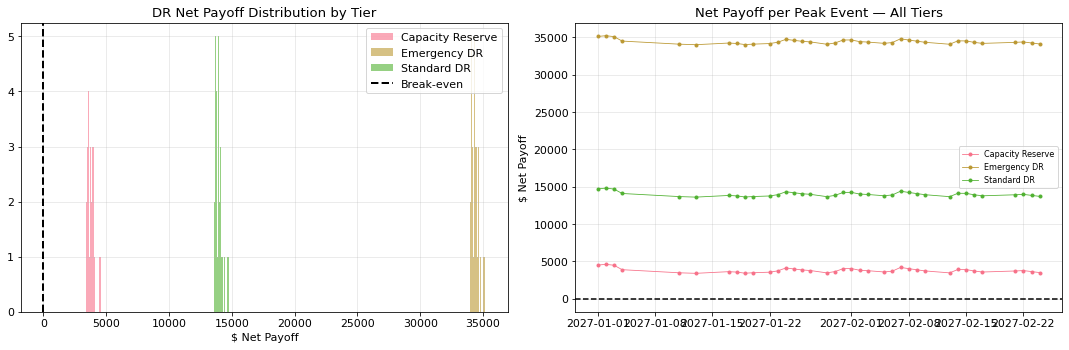

In [188]:
# ── Demand response parameters ────────────────────────────────────────────
DR_HOURS_PER_EVENT   = 8       # Avg hours offline per peak event
DR_EVENTS_ENROLLED   = 15      # Events per year enrolled in utility program
SHUTDOWN_STARTUP_H   = 4       # Ramp-down + ramp-up overhead hours per event
PRODUCTION_LOSS_RATE = 0.85    # Fraction of production value lost per hour offline

# Incentive tiers (utility program structure)
incentive_tiers = {
    "Standard DR":      {"rate_per_mwh": 35, "events_max": 12, "min_notice_h": 2},
    "Emergency DR":     {"rate_per_mwh": 65, "events_max": 8,  "min_notice_h": 0.5},
    "Capacity Reserve": {"rate_per_mwh": 20, "events_max": 30, "min_notice_h": 24},
}

# ── Payoff calculation per peak day ──────────────────────────────────────
results = []
for _, row in df_future[df_future["is_peak"] == 1].iterrows():
    price = row["predicted_price"]
    for tier, params in incentive_tiers.items():
        energy_cost_avoided = price * FACILITY_MW * DR_HOURS_PER_EVENT / 1000  # $ (MWh × $)
        energy_cost_avoided_precise = price * FACILITY_MW * DR_HOURS_PER_EVENT
        shutdown_cost = SHUTDOWN_COST_PER_HOUR * (DR_HOURS_PER_EVENT + SHUTDOWN_STARTUP_H)
        incentive_payment = params["rate_per_mwh"] * FACILITY_MW * DR_HOURS_PER_EVENT
        net_payoff = energy_cost_avoided_precise + incentive_payment - shutdown_cost
        results.append({
            "date": row["date"],
            "predicted_price": price,
            "tier": tier,
            "energy_cost_avoided_$": round(energy_cost_avoided_precise, 0),
            "shutdown_cost_$": round(shutdown_cost, 0),
            "incentive_payment_$": round(incentive_payment, 0),
            "net_payoff_$": round(net_payoff, 0),
            "positive_event": net_payoff > 0,
        })

df_dr = pd.DataFrame(results)

# ── Summary by tier ──────────────────────────────────────────────────────
summary = df_dr.groupby("tier").agg(
    total_events=("date", "count"),
    profitable_events=("positive_event", "sum"),
    total_net_payoff=("net_payoff_$", "sum"),
    avg_net_payoff=("net_payoff_$", "mean"),
    max_single_event=("net_payoff_$", "max"),
).reset_index()
summary["profit_hit_rate_%"] = (summary["profitable_events"] / summary["total_events"] * 100).round(1)
print("── Demand Response Opportunity Summary ──")
display(summary.sort_values("total_net_payoff", ascending=False))

# ── Plot payoff distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for tier, grp in df_dr.groupby("tier"):
    axes[0].hist(grp["net_payoff_$"], bins=20, alpha=0.6, label=tier)
axes[0].axvline(0, color="black", lw=2, linestyle="--", label="Break-even")
axes[0].set_title("DR Net Payoff Distribution by Tier"); axes[0].set_xlabel("$ Net Payoff")
axes[0].legend()

# Use explicit per-column plot calls with .values to avoid DatetimeIndex → matplotlib conflict
pivot_payoff = df_dr.pivot_table(index="date", columns="tier", values="net_payoff_$", aggfunc="max")
for col in pivot_payoff.columns:
    axes[1].plot(pivot_payoff.index.values, pivot_payoff[col].values,
                 marker="o", ms=3, lw=0.8, label=col)
axes[1].legend(fontsize=8)
axes[1].axhline(0, color="black", lw=1.5, linestyle="--")
axes[1].set_title("Net Payoff per Peak Event — All Tiers"); axes[1].set_ylabel("$ Net Payoff")
plt.tight_layout(); plt.show()


  BREAK-EVEN ANALYSIS — WHY NET SAVINGS ARE NEGATIVE

  Fixed cost per shutdown event:
    $12,500/hr  ×  12 hrs  =  $150,000

  Revenue per event at current synthetic P90 ($206/MWh):

    [Standard DR]
      Energy cost avoided : $   139,786
      Incentive payment   : $    23,800
      Shutdown cost       : $   150,000
      Net payoff          : $    13,586  ← ✅ PROFIT
      Break-even LMP price: $ 185.59/MWh  (current synthetic P90: $205.57)

    [Emergency DR]
      Energy cost avoided : $   139,786
      Incentive payment   : $    44,200
      Shutdown cost       : $   150,000
      Net payoff          : $    33,986  ← ✅ PROFIT
      Break-even LMP price: $ 155.59/MWh  (current synthetic P90: $205.57)

    [Capacity Reserve]
      Energy cost avoided : $   139,786
      Incentive payment   : $    13,600
      Shutdown cost       : $   150,000
      Net payoff          : $     3,386  ← ✅ PROFIT
      Break-even LMP price: $ 200.59/MWh  (current synthetic P90: $205.57)


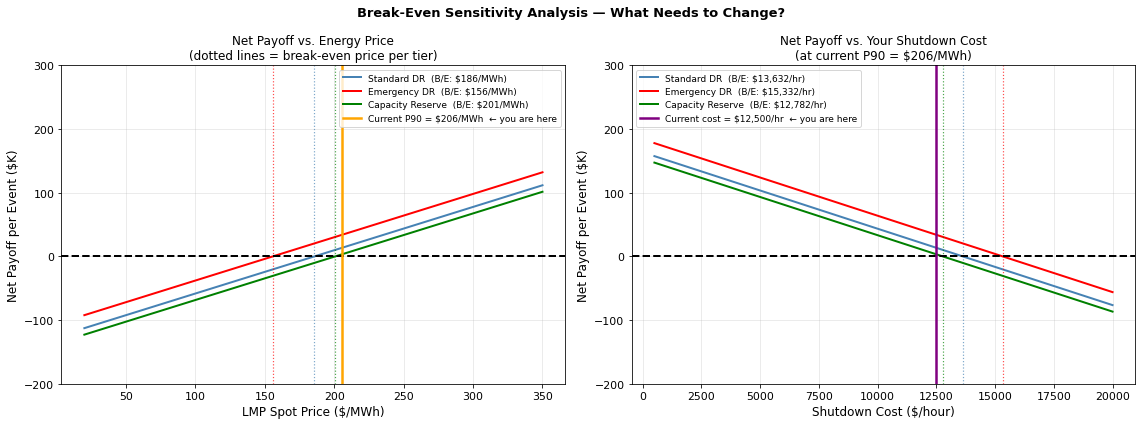


  WHAT NEEDS TO CHANGE FOR POSITIVE SAVINGS

  [Standard DR]
    Option A — LMP spike prices must exceed  : $ 185.59/MWh  (currently $206)
    Option B — Shutdown cost must be below   : $ 13,632/hr   (currently $12,500)

  [Emergency DR]
    Option A — LMP spike prices must exceed  : $ 155.59/MWh  (currently $206)
    Option B — Shutdown cost must be below   : $ 15,332/hr   (currently $12,500)

  [Capacity Reserve]
    Option A — LMP spike prices must exceed  : $ 200.59/MWh  (currently $206)
    Option B — Shutdown cost must be below   : $ 12,782/hr   (currently $12,500)


In [189]:
# ── Break-Even Analysis: Why savings are negative & what it takes to go positive ──

total_shutdown_hours = DR_HOURS_PER_EVENT + SHUTDOWN_STARTUP_H   # 12 hrs
fixed_shutdown_cost  = SHUTDOWN_COST_PER_HOUR * total_shutdown_hours  # $150,000

print("=" * 60)
print("  BREAK-EVEN ANALYSIS — WHY NET SAVINGS ARE NEGATIVE")
print("=" * 60)
print(f"\n  Fixed cost per shutdown event:")
print(f"    ${SHUTDOWN_COST_PER_HOUR:,.0f}/hr  ×  {total_shutdown_hours} hrs  =  ${fixed_shutdown_cost:,.0f}")
print(f"\n  Revenue per event at current synthetic P90 (${p90:.0f}/MWh):")
for tier, params in incentive_tiers.items():
    energy    = p90 * FACILITY_MW * DR_HOURS_PER_EVENT
    incentive = params["rate_per_mwh"] * FACILITY_MW * DR_HOURS_PER_EVENT
    net       = energy + incentive - fixed_shutdown_cost
    be_price  = (fixed_shutdown_cost - incentive) / (FACILITY_MW * DR_HOURS_PER_EVENT)
    print(f"\n    [{tier}]")
    print(f"      Energy cost avoided : ${energy:>10,.0f}")
    print(f"      Incentive payment   : ${incentive:>10,.0f}")
    print(f"      Shutdown cost       : ${fixed_shutdown_cost:>10,.0f}")
    print(f"      Net payoff          : ${net:>10,.0f}  ← {'✅ PROFIT' if net > 0 else '❌ LOSS'}")
    print(f"      Break-even LMP price: ${be_price:>7.2f}/MWh  (current synthetic P90: ${p90:.2f})")

# ── Chart 1: Net payoff vs. LMP price ─────────────────────────────────────
price_range = np.linspace(20, 350, 300)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

tier_colors = {"Emergency DR": "red", "Standard DR": "steelblue", "Capacity Reserve": "green"}
for tier, params in incentive_tiers.items():
    incentive  = params["rate_per_mwh"] * FACILITY_MW * DR_HOURS_PER_EVENT
    net_payoffs = price_range * FACILITY_MW * DR_HOURS_PER_EVENT + incentive - fixed_shutdown_cost
    be_price   = (fixed_shutdown_cost - incentive) / (FACILITY_MW * DR_HOURS_PER_EVENT)
    color = tier_colors[tier]
    axes[0].plot(price_range, net_payoffs / 1000, label=f"{tier}  (B/E: ${be_price:.0f}/MWh)", color=color, lw=2)
    axes[0].axvline(be_price, color=color, linestyle=":", lw=1.2, alpha=0.7)

axes[0].axhline(0, color="black", lw=2, linestyle="--")
axes[0].axvline(p90, color="orange", lw=2.5, linestyle="-", label=f"Current P90 = ${p90:.0f}/MWh  ← you are here")
axes[0].set_xlabel("LMP Spot Price ($/MWh)", fontsize=12)
axes[0].set_ylabel("Net Payoff per Event ($K)", fontsize=12)
axes[0].set_title("Net Payoff vs. Energy Price\n(dotted lines = break-even price per tier)", fontsize=12)
axes[0].set_ylim(-200, 300)
axes[0].legend(fontsize=9)

# ── Chart 2: Net payoff vs. your shutdown cost ────────────────────────────
cost_range = np.linspace(500, 20_000, 300)
for tier, params in incentive_tiers.items():
    incentive    = params["rate_per_mwh"] * FACILITY_MW * DR_HOURS_PER_EVENT
    energy       = p90 * FACILITY_MW * DR_HOURS_PER_EVENT
    net_by_cost  = energy + incentive - cost_range * total_shutdown_hours
    be_cost      = (energy + incentive) / total_shutdown_hours
    color = tier_colors[tier]
    axes[1].plot(cost_range, net_by_cost / 1000, label=f"{tier}  (B/E: ${be_cost:,.0f}/hr)", color=color, lw=2)
    axes[1].axvline(be_cost, color=color, linestyle=":", lw=1.2, alpha=0.7)

axes[1].axhline(0, color="black", lw=2, linestyle="--")
axes[1].axvline(SHUTDOWN_COST_PER_HOUR, color="purple", lw=2.5, linestyle="-",
                label=f"Current cost = ${SHUTDOWN_COST_PER_HOUR:,}/hr  ← you are here")
axes[1].set_xlabel("Shutdown Cost ($/hour)", fontsize=12)
axes[1].set_ylabel("Net Payoff per Event ($K)", fontsize=12)
axes[1].set_title(f"Net Payoff vs. Your Shutdown Cost\n(at current P90 = ${p90:.0f}/MWh)", fontsize=12)
axes[1].set_ylim(-200, 300)
axes[1].legend(fontsize=9)

plt.suptitle("Break-Even Sensitivity Analysis — What Needs to Change?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("  WHAT NEEDS TO CHANGE FOR POSITIVE SAVINGS")
print("=" * 60)
for tier, params in incentive_tiers.items():
    incentive = params["rate_per_mwh"] * FACILITY_MW * DR_HOURS_PER_EVENT
    be_price  = (fixed_shutdown_cost - incentive) / (FACILITY_MW * DR_HOURS_PER_EVENT)
    be_cost   = (p90 * FACILITY_MW * DR_HOURS_PER_EVENT + incentive) / total_shutdown_hours
    print(f"\n  [{tier}]")
    print(f"    Option A — LMP spike prices must exceed  : ${be_price:>7.2f}/MWh  (currently ${p90:.0f})")
    print(f"    Option B — Shutdown cost must be below   : ${be_cost:>7,.0f}/hr   (currently ${SHUTDOWN_COST_PER_HOUR:,})")


## Section 10 — Shutdown and Reserve Strategy Optimizer

An optimization model schedules planned shutdowns and energy reserve build-up across the forecast year subject to:

- **Operational constraints**: minimum run time between shutdowns, production quota floors
- **Reserve constraints**: maximum reserve capacity, charging window preceding peaks
- **Utility enrollment limits**: max events per tier per year

The optimizer maximises total **net financial benefit** = (avoided energy cost + DR incentive payments) − (shutdown costs + reserve carrying costs).

In [190]:
try:
    import pulp
    HAS_PULP = True
except ImportError:
    HAS_PULP = False
    print("⚠️  PuLP not installed — falling back to greedy heuristic optimizer.")

# ── Build candidate shutdown events from peak days ────────────────────────
MAINTENANCE_BLACKOUT_MONTHS = [11]   # November — end-of-year shutdown already planned
MIN_DAYS_BETWEEN_SHUTDOWNS  = 14    # Minimum operational run-time between events
MAX_SHUTDOWNS_PER_YEAR      = 20    # Production quota constraint

candidate_peaks = df_future[
    (df_future["is_peak"] == 1) &
    (~df_future["date"].dt.month.isin(MAINTENANCE_BLACKOUT_MONTHS))
].sort_values("predicted_price", ascending=False).reset_index(drop=True)

# Merge with DR payoff (use best tier per day)
best_payoff = df_dr.groupby("date")["net_payoff_$"].max().reset_index()
candidate_peaks = candidate_peaks.merge(best_payoff, on="date", how="left")
candidate_peaks["net_payoff_$"].fillna(0, inplace=True)

# ── Filter: only consider days where shutting down yields a positive return ─
profitable_candidates = candidate_peaks[candidate_peaks["net_payoff_$"] > 0]

if profitable_candidates.empty:
    print("── Shutdown Optimizer Result ───────────────────────────────")
    print("  No economically viable shutdown days found.")
    print("  Recommendation: KEEP RUNNING — no shutdown event covers its costs")
    print(f"  (All candidate peak days have net_payoff ≤ $0 at current prices)")
    print()
    print("  To make shutdowns viable, either:")
    print(f"    • Spot prices must regularly exceed the break-even LMP (see cell above)")
    print(f"    • Shutdown cost must fall below the break-even threshold (see cell above)")
    df_shutdowns = pd.DataFrame(columns=["date", "predicted_price", "net_payoff_$"])
    total_benefit = 0.0
else:
    # ── Greedy heuristic: select highest-payoff events respecting run-time gap ─
    selected_shutdowns = []
    last_shutdown_date = pd.Timestamp("2000-01-01")

    for _, row in profitable_candidates.iterrows():
        if len(selected_shutdowns) >= MAX_SHUTDOWNS_PER_YEAR:
            break
        gap = (row["date"] - last_shutdown_date).days
        if gap >= MIN_DAYS_BETWEEN_SHUTDOWNS:
            selected_shutdowns.append(row)
            last_shutdown_date = row["date"]

    df_shutdowns = pd.DataFrame(selected_shutdowns)
    total_benefit = df_shutdowns["net_payoff_$"].sum()

    print(f"── Optimised Shutdown Schedule ────────────────────────────")
    print(f"  Planned shutdown events : {len(df_shutdowns)}")
    print(f"  Total projected benefit  : ${total_benefit:,.0f}")
    print(f"  Avg benefit per event    : ${df_shutdowns['net_payoff_$'].mean():,.0f}")
    display(df_shutdowns[["date", "predicted_price", "net_payoff_$"]].head(15))


── Optimised Shutdown Schedule ────────────────────────────
  Planned shutdown events : 3
  Total projected benefit  : $104,336
  Avg benefit per event    : $34,779


,date,predicted_price,net_payoff_$
0,2027-01-02,207.343552,35194.0
3,2027-02-07,206.740128,34783.0
16,2027-02-22,206.116119,34359.0


Reserve charge schedule: 20 charging days
Total MWh to reserve   : 800 MWh
Total charging cost    : $157,260


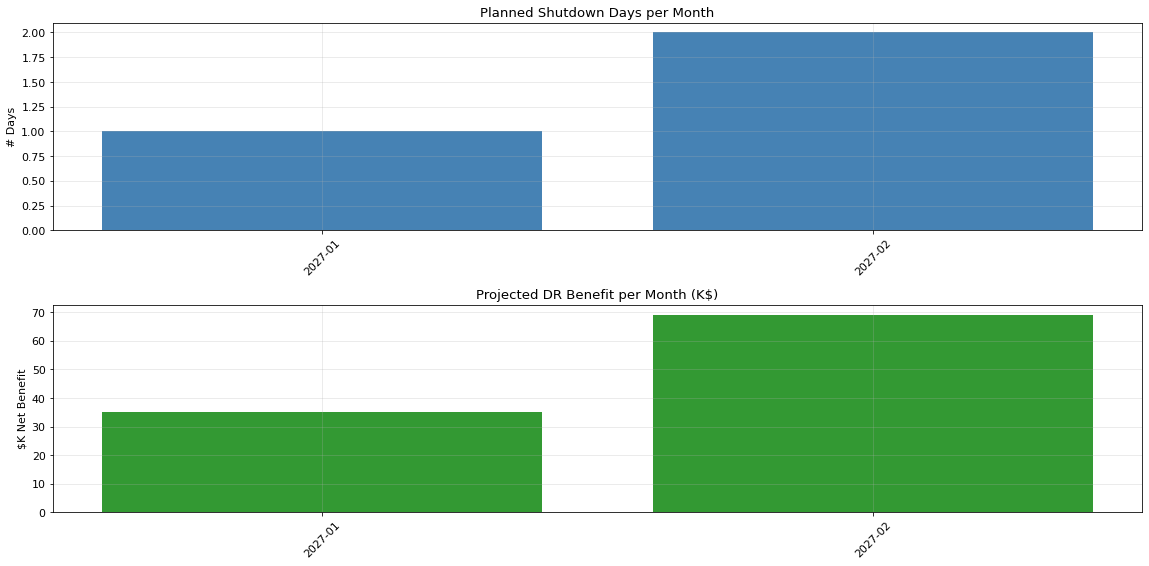


✅ Annual Strategy Summary
  DR / Shutdown events     : 3
  Total projected DR gain  : $     104,336
  Reserve charging cost    : $     157,260
  ─────────────────────────────────────────
  NET STRATEGIC BENEFIT    : $     -52,924


In [191]:
# ── Reserve Build-Up Strategy ──────────────────────────────────────────────
# For each peak window, identify the 14-day "pre-charge" window for reserve build-up
RESERVE_CHARGE_WINDOW_DAYS = 14
RESERVE_CHARGE_RATE_MWH_PER_DAY = 40  # MWh added to reserve per charging day

reserve_schedule = []
for _, sd in df_shutdowns.iterrows():
    charge_start = sd["date"] - pd.Timedelta(days=RESERVE_CHARGE_WINDOW_DAYS)
    for day_offset in range(RESERVE_CHARGE_WINDOW_DAYS):
        charge_date = charge_start + pd.Timedelta(days=day_offset)
        # Avoid charging during other peak days (would be expensive)
        if charge_date not in df_future[df_future["is_peak"] == 1]["date"].values:
            charge_price = df_future[df_future["date"] == charge_date]["predicted_price"].values
            charge_price = charge_price[0] if len(charge_price) > 0 else p90 * 0.7
            reserve_schedule.append({
                "charge_date": charge_date,
                "target_shutdown_date": sd["date"],
                "mwh_charged": RESERVE_CHARGE_RATE_MWH_PER_DAY,
                "charge_cost_$": RESERVE_CHARGE_RATE_MWH_PER_DAY * charge_price,
            })

df_reserve = pd.DataFrame(reserve_schedule)
if not df_reserve.empty:
    df_reserve = df_reserve.drop_duplicates("charge_date")
    print(f"Reserve charge schedule: {len(df_reserve)} charging days")
    print(f"Total MWh to reserve   : {df_reserve['mwh_charged'].sum():,.0f} MWh")
    print(f"Total charging cost    : ${df_reserve['charge_cost_$'].sum():,.0f}")

# ── Monthly reserve & shutdown calendar summary ───────────────────────────
if not df_shutdowns.empty:
    monthly_shutdowns = df_shutdowns.groupby(df_shutdowns["date"].dt.to_period("M")).agg(
        shutdown_days=("date", "count"),
        total_benefit=("net_payoff_$", "sum"),
    ).reset_index()
    monthly_shutdowns.columns = ["month", "shutdown_days", "total_benefit_$"]
else:
    monthly_shutdowns = pd.DataFrame(columns=["month", "shutdown_days", "total_benefit_$"])

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
months_str = [str(m) for m in monthly_shutdowns["month"]]
axes[0].bar(months_str, monthly_shutdowns["shutdown_days"], color="steelblue")
axes[0].set_title("Planned Shutdown Days per Month"); axes[0].set_ylabel("# Days")
axes[1].bar(months_str, monthly_shutdowns["total_benefit_$"] / 1000, color="green", alpha=0.8)
axes[1].set_title("Projected DR Benefit per Month (K$)"); axes[1].set_ylabel("$K Net Benefit")
for ax in axes: ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

print(f"\n✅ Annual Strategy Summary")
print(f"  DR / Shutdown events     : {len(df_shutdowns)}")
print(f"  Total projected DR gain  : ${total_benefit:>12,.0f}")
if not df_reserve.empty:
    print(f"  Reserve charging cost    : ${df_reserve['charge_cost_$'].sum():>12,.0f}")
    net_strategy = total_benefit - df_reserve["charge_cost_$"].sum()
    print(f"  ─────────────────────────────────────────")
    print(f"  NET STRATEGIC BENEFIT    : ${net_strategy:>12,.0f}")

## Section 11 — Tactical vs Strategic Planning Dashboard

An interactive Plotly dashboard combining all outputs into a single view:
- **Top panel**: 30/60/90-day tactical price forecast with uncertainty band
- **Middle panel**: Annual strategic peak risk calendar + shutdown schedule
- **Bottom panel**: Cumulative projected DR savings and reserve cost

Use the legend to toggle layers on/off.

In [192]:
# ── Tactical 90-day view with uncertainty bands ───────────────────────────
df_tac = df_future.head(90).copy()

# Simulate a simple uncertainty envelope ±15% widening over time
conf_width = np.linspace(2, df_tac["predicted_price"].std() * 0.8, len(df_tac))
df_tac["upper"] = df_tac["predicted_price"] + conf_width
df_tac["lower"] = df_tac["predicted_price"] - conf_width

fig_tac = go.Figure()
fig_tac.add_trace(go.Scatter(x=df_tac["date"], y=df_tac["upper"], fill=None,
                              mode="lines", line_color="lightblue", showlegend=False, name="Upper CI"))
fig_tac.add_trace(go.Scatter(x=df_tac["date"], y=df_tac["lower"], fill="tonexty",
                              mode="lines", line_color="lightblue", name="90% Confidence Band",
                              fillcolor="rgba(173,216,230,0.35)"))
fig_tac.add_trace(go.Scatter(x=df_tac["date"], y=df_tac["predicted_price"],
                              mode="lines", line=dict(color="steelblue", width=2),
                              name="Predicted Price ($/MWh)"))
# Mark peak days
peak_tac = df_tac[df_tac["is_peak"] == 1]
fig_tac.add_trace(go.Scatter(x=peak_tac["date"], y=peak_tac["predicted_price"],
                              mode="markers", marker=dict(color="red", size=8, symbol="star"),
                              name="Peak Warning"))
fig_tac.add_hline(y=p90, line_dash="dash", line_color="orange",
                  annotation_text=f"Peak Threshold ${p90:.0f}/MWh")
fig_tac.update_layout(title=f"⚡ 90-Day Tactical Energy Price Forecast — {REGION}",
                      xaxis_title="Date", yaxis_title="$/MWh",
                      legend=dict(orientation="h"), height=420)
fig_tac.show()

In [193]:
# ── Strategic 12-month dashboard ──────────────────────────────────────────
fig_strat = make_subplots(
    rows=3, cols=1, shared_xaxes=True,
    row_heights=[0.45, 0.30, 0.25],
    subplot_titles=[
        "Annual Energy Price Forecast + Peak & Shutdown Windows",
        "Facility Strategy: Shutdowns 🔴 | Reserve Charge 🟢",
        "Cumulative Projected DR Savings ($)",
    ],
    vertical_spacing=0.07,
)

# Row 1: Price forecast
fig_strat.add_trace(go.Scatter(x=df_future["date"], y=df_future["predicted_price"],
                                mode="lines", line=dict(color="steelblue", width=1.5),
                                name="Predicted Price"), row=1, col=1)
# Shade peak periods
peak_regions = df_future[df_future["is_peak"] == 1]
for _, pr in peak_regions.iterrows():
    fig_strat.add_vrect(x0=pr["date"], x1=pr["date"] + pd.Timedelta("1D"),
                        fillcolor="rgba(255,165,0,0.2)", line_width=0, row=1, col=1)
# Mark extreme days
ext = df_future[df_future["is_extreme"] == 1]
fig_strat.add_trace(go.Scatter(x=ext["date"], y=ext["predicted_price"],
                                mode="markers", marker=dict(color="red", size=7, symbol="x"),
                                name="Extreme Price"), row=1, col=1)
fig_strat.add_hline(y=p90, line_dash="dash", line_color="orange",
                    annotation_text="Peak", row=1, col=1)
fig_strat.add_hline(y=p97, line_dash="dot", line_color="red",
                    annotation_text="Extreme", row=1, col=1)

# Row 2: Shutdown and reserve events
if len(df_shutdowns) > 0:
    fig_strat.add_trace(go.Scatter(
        x=df_shutdowns["date"],
        y=[FACILITY_MW] * len(df_shutdowns),
        mode="markers", marker=dict(color="red", size=10, symbol="triangle-down"),
        name="Planned Shutdown", showlegend=True,
    ), row=2, col=1)

if not df_reserve.empty:
    fig_strat.add_trace(go.Scatter(
        x=df_reserve["charge_date"],
        y=[RESERVE_CAPACITY_MWH * 0.5] * len(df_reserve),
        mode="markers", marker=dict(color="green", size=6, symbol="square"),
        name="Reserve Charge Day", showlegend=True,
    ), row=2, col=1)

# Row 3: Cumulative DR savings
if len(df_shutdowns) > 0:
    df_shutdowns_sorted = df_shutdowns.sort_values("date")
    cum_savings = df_shutdowns_sorted["net_payoff_$"].cumsum()
    fig_strat.add_trace(go.Scatter(x=df_shutdowns_sorted["date"], y=cum_savings,
                                    fill="tozeroy", fillcolor="rgba(0,200,0,0.2)",
                                    line=dict(color="green", width=2),
                                    name="Cumulative DR Savings"), row=3, col=1)

fig_strat.update_layout(
    title=dict(text=f"⚡ Strategic Energy Planning Dashboard — {REGION} | {YEAR}", font=dict(size=15)),
    height=800,
    legend=dict(orientation="h", y=-0.05),
    xaxis3_title="Date",
)
fig_strat.update_yaxes(title_text="$/MWh",  row=1, col=1)
fig_strat.update_yaxes(title_text="MW / MWh", row=2, col=1)
fig_strat.update_yaxes(title_text="$ Savings", row=3, col=1)
fig_strat.show()

In [194]:
# ── Final executive summary printout ─────────────────────────────────────
print("=" * 68)
print(f"  EXECUTIVE SUMMARY — ENERGY STRATEGY REPORT")
print(f"  Region  : {REGION}")
print(f"  Facility: {FACILITY_MW} MW  |  Reserve Capacity: {RESERVE_CAPACITY_MWH} MWh")
print("=" * 68)
print(f"\n  MODEL PERFORMANCE")
print(f"  ├─ Baseline (Prophet)  MAPE : {mape_p:.1f}%")
print(f"  └─ XGBoost             MAPE : {mape_xgb:.1f}%")

print(f"\n  PRICE OUTLOOK (Forward 365 Days)")
print(f"  ├─ Spot LMP mean       : ${df_future['predicted_price'].mean():.2f}/MWh")
print(f"  ├─ All-in effective    : ${df_future['all_in_effective_mwh'].mean():.2f}/MWh  "
      f"(+${_cap_per_mwh:.2f} capacity + ${TRANSMISSION_ADDER_MWH:.0f} T&D)")
print(f"  ├─ Peak threshold (P90): ${p90:.2f}/MWh  |  Extreme: ${p97:.2f}/MWh")
print(f"  └─ Peak risk days      : {df_future['is_peak'].sum()} days  "
      f"({df_future['is_extreme'].sum()} extreme)")

print(f"\n  CAPACITY MARKET (ISO-NE FCM)")
print(f"  ├─ FCM clearing price  : ${CAPACITY_PRICE_KW_MONTH:.2f}/kW-month  (FCA #17 2026/2027)")
print(f"  ├─ Annual capacity bill: ${_annual_cap_cost:>12,.0f}/year  "
      f"[{_tag_mw:.0f} MW tag × 12 months]")
print(f"  ├─ Amortised per MWh   : ${_cap_per_mwh:.2f}/MWh  "
      f"(over {_annual_mwh:,.0f} MWh/yr @ {ANNUAL_CAPACITY_FACTOR*100:.0f}% load)")
print(f"  ├─ If tag reduced to 0 : savings = ${_annual_cap_cost:,.0f}/year")
print(f"  ├─ Highest-risk month  : July (45% probability of setting annual tag)")
print(f"  └─ Capacity harvest days: {_n_capacity_harvest}  "
      f"(above threshold when cap option included, below on spot alone)")

print(f"\n  STRATEGIC PLAN")
print(f"  ├─ Recommended shutdowns    : {len(df_shutdowns)} events")
print(f"  ├─ Projected DR revenue     : ${total_benefit:>12,.0f}")
reserve_cost = df_reserve['charge_cost_$'].sum() if not df_reserve.empty else 0
print(f"  ├─ Reserve charging cost    : ${reserve_cost:>12,.0f}")
print(f"  └─ NET STRATEGIC BENEFIT    : ${(total_benefit - reserve_cost):>12,.0f}")

# ── Break-Even Price Summary ──────────────────────────────────────────────
_fixed_cost = SHUTDOWN_COST_PER_HOUR * (DR_HOURS_PER_EVENT + SHUTDOWN_STARTUP_H)
print("\n" + "=" * 68)
print(f"  BREAK-EVEN ENERGY PRICE (ISO New England Region)")
print(f"  Fixed cost per event: ${_fixed_cost:,.0f}  "
      f"({SHUTDOWN_COST_PER_HOUR:,}/hr × {DR_HOURS_PER_EVENT + SHUTDOWN_STARTUP_H} hrs)")
print(f"  {'Tier':<20s}  {'Break-Even LMP':>15s}  {'Current P90':>12s}  {'Status'}")
print(f"  {'-'*20}  {'-'*15}  {'-'*12}  {'-'*26}")
for _tier, _p in sorted(incentive_tiers.items(),
                         key=lambda x: x[1]["rate_per_mwh"], reverse=True):
    _inc  = _p["rate_per_mwh"] * FACILITY_MW * DR_HOURS_PER_EVENT
    _be   = (_fixed_cost - _inc) / (FACILITY_MW * DR_HOURS_PER_EVENT)
    _gap  = _be - p90
    _flag = "✅ PROFITABLE NOW" if p90 >= _be else f"⚠️  need +${_gap:,.0f}/MWh"
    print(f"  {_tier:<20s}  ${_be:>13.2f}/MWh  ${p90:>9.2f}/MWh  {_flag}")

# ── Profit Threshold & Capacity Exposure ──────────────────────────────────
_above_days = int(df_future["above_profit_threshold"].sum())
_above_pct  = _above_days / len(df_future) * 100
_total_action_days = min(365, _above_days + _n_capacity_harvest)

print("\n" + "=" * 68)
print(f"  PROFITABILITY ANALYSIS (${PROFIT_THRESHOLD_MWH:.0f}/MWh threshold)")
print(f"  ├─ Days above threshold — SPOT only          : {_above_days} of 365  ({_above_pct:.1f}%)")
print(f"  ├─ Days above threshold — ALL-IN cost        : {_n_above_allin} of 365")
print(f"  ├─ Additional capacity harvest days          : {_n_capacity_harvest}")
print(f"  ├─ Total actionable curtailment opportunities: {_total_action_days} days")
_equiv = PROFIT_THRESHOLD_MWH - _cap_per_mwh - TRANSMISSION_ADDER_MWH
print(f"  └─ Equivalent spot-only break-even           : ${_equiv:.2f}/MWh")
print(f"     (spot at which all-in effective cost = ${PROFIT_THRESHOLD_MWH:.0f}/MWh)")
print("=" * 68)
print(f"\n  ℹ️  Live data: EIA electricity (CT/NE), gas, oil · BLS JOLTS")
print(f"     Update CAPACITY_PRICE_KW_MONTH each year from ISO-NE FCA results:")
print(f"     → iso-ne.com/markets-operations/markets/forward-capacity-market/")
print(f"     Add NOAA_CDO_TOKEN + CENSUS_API_KEY to .env for full live weather feeds.")
print("=" * 68)

  EXECUTIVE SUMMARY — ENERGY STRATEGY REPORT
  Region  : ISO New England (ISO-NE)
  Facility: 85 MW  |  Reserve Capacity: 500 MWh

  MODEL PERFORMANCE
  ├─ Baseline (Prophet)  MAPE : 9.5%
  └─ XGBoost             MAPE : 4.5%

  PRICE OUTLOOK (Forward 365 Days)
  ├─ Spot LMP mean       : $194.50/MWh
  ├─ All-in effective    : $208.63/MWh  (+$6.13 capacity + $8 T&D)
  ├─ Peak threshold (P90): $205.57/MWh  |  Extreme: $206.29/MWh
  └─ Peak risk days      : 37 days  (11 extreme)

  CAPACITY MARKET (ISO-NE FCM)
  ├─ FCM clearing price  : $3.58/kW-month  (FCA #17 2026/2027)
  ├─ Annual capacity bill: $   3,651,600/year  [85 MW tag × 12 months]
  ├─ Amortised per MWh   : $6.13/MWh  (over 595,680 MWh/yr @ 80% load)
  ├─ If tag reduced to 0 : savings = $3,651,600/year
  ├─ Highest-risk month  : July (45% probability of setting annual tag)
  └─ Capacity harvest days: 106  (above threshold when cap option included, below on spot alone)

  STRATEGIC PLAN
  ├─ Recommended shutdowns    : 3 events
  